# Import Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
from scipy import signal, interpolate
import scipy.stats as stat
from scipy.stats import linregress, norm
from scipy.interpolate import interp1d
from scipy.signal import csd, get_window, periodogram, spectral, butter, lfilter, sosfilt, windows, find_peaks, blackman
from astropy.timeseries import LombScargle
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import warnings 
warnings.filterwarnings("ignore")


# Define Functions

In [2]:
def movingaverage(interval, window_size):
    window= np.ones(int(window_size))/float(window_size)
    return np.convolve(interval, window, 'same')

# Import Data

## Previously Published Data
Pena et al., 2008: original data available upon request to the authors.
Rippert et al., 2017: https://doi.org/10.1594/PANGAEA.870412. 
Rafter and Charles, 2012: https://www.ncei.noaa.gov/access/paleo-search/study/13607?siteId=19108. 
Lisiecki and Raymo, 2005: https://lorraine-lisiecki.com/stack.html

In [3]:
lr04 = pd.read_excel('Pallone_25_Data_9.xlsx',sheet_name='lr04')

In [4]:
pena2008_ruber_18O = pd.read_excel('Pallone_25_Data_3.xlsx',sheet_name='G. ruber d18O') # Pena et al., 2008
pena2008_duter_18O = pd.read_excel('Pallone_25_Data_3.xlsx',sheet_name='N. dutertrei d18O') # Pena et al., 2008
pena2008_duter_13C = pd.read_excel('Pallone_25_Data_3.xlsx',sheet_name='N. dutertrei d13C') # Pena et al., 2008
pena2008_ruber_mgca = pd.read_excel('Pallone_25_Data_3.xlsx', sheet_name='G. ruber SST', dtype={'G. ruber SST (˚C)': float}) # Pena et al., 2008
pena2008_duter_mgca = pd.read_excel('Pallone_25_Data_3.xlsx', sheet_name='N. dutertrei DTT', dtype={'N. dutertrei DTT (˚C)': float}) # Pena et al., 2008
d18Osw_dut = pd.read_excel('Pallone_25_Data_3.xlsx', sheet_name='N. dutertrei d18Osw') # Pena et al., 2008
d18Osw_rub = pd.read_excel('Pallone_25_Data_3.xlsx', sheet_name='G. ruber d18Osw') # Pena et al., 2008


ripert2017_hex = pd.read_excel('Pallone_25_Data_3.xlsx',sheet_name='G. hexagonus d18O') # Rippert et al., 2017
hex13C = pd.read_excel('Pallone_25_Data_3.xlsx',sheet_name='G. hexagonus d13C') # Rippert et al., 2017
hex13C = hex13C.dropna(subset=['G. hexagonus δ13C (‰) VPDB'])

rafter = pd.read_excel('Pallone_25_Data_8.xlsx',sheet_name='Sheet1') # Rafter and Charles, 2012

## Insolation Values 
Laskar et al., 2004: https://vo.imcce.fr/insola/earth/online/earth/online/index.php

In [5]:
august = pd.read_excel('Pallone_25_Data_7.xlsx',sheet_name='August 21 0') # Laskar et al., 2004
september = pd.read_excel('Pallone_25_Data_7.xlsx',sheet_name='September 21 0') # Laskar et al., 2004
nhsi = pd.read_excel('Pallone_25_Data_7.xlsx',sheet_name='June 21 65') # Laskar et al., 2004

## Synthetic Random Datasets

In [81]:
#### Note: this will make different random datasets than those used in this manuscript. For the exact versions of these randomized datasets used to create the figures, please see Pallone_2025_Data_9.xlsx
## Option to create new datasets
size = 160

## 1
ages1 = np.arange(0,160,1)
values1 = np.random.normal(size=size)

random1_dict = {'age_ka': ages1, 'value': values1}
random1 = pd.DataFrame(random1_dict)

## 2
ages2 = np.arange(0,160,1)
values2 = np.random.normal(size=size)

random2_dict = {'age_ka': ages2, 'value': values2}
random2 = pd.DataFrame(random2_dict)

## 3
ages3 = np.arange(0,160,1)
values3 = np.random.normal(size=size)

random3_dict = {'age_ka': ages3, 'value': values3}
random3 = pd.DataFrame(random3_dict)

In [7]:
## Use existing datasets

random1 = pd.read_excel('Pallone_25_Data_9.xlsx',sheet_name='random1')
random2 = pd.read_excel('Pallone_25_Data_9.xlsx',sheet_name='random2')
random3 = pd.read_excel('Pallone_25_Data_9.xlsx',sheet_name='random3')

## New Planktic Foraminifera d18O from ODP 1240

In [8]:
tum = pd.read_excel('Pallone_25_Data_2.xlsx', sheet_name='G. tumida')
obliq = pd.read_excel('Pallone_25_Data_2.xlsx', sheet_name='P. obliquiloculata')
menardii = pd.read_excel('Pallone_25_Data_2.xlsx', sheet_name='G. menardii')
sacc = pd.read_excel('Pallone_25_Data_2.xlsx', sheet_name='T. sacculifer')

## Late Holocene Foraminifera d18O values for modern calibration

In [9]:
ruber_d18O = pena2008_ruber_18O['G. ruber δ18O (‰) VPDB'][0]
sacc_d18O = sacc['d18O'][0] # from 3.45 ka, no core top sample 
men_d18O = menardii['d18O'][0]
tum_d18O = tum['d18O'][0]
dut_d18O = pena2008_duter_18O['N. dutertrei δ18O (‰) VPDB'][0]
obliq_d18O = obliq['d18O'][0]
hex_d18O = ripert2017_hex['G. hexagonus δ18O (‰) VPDB'][0]

##  Ford et al., 2018 depth ranges for species

In [10]:
ruber_depth = 14
sacc_depth = 29
obliq_depth = 64
men_depth = 47
dut_depth = 76
tum_depth = 106

ruber_err = 10
sacc_err = 14
obliq_err = 24
men_err = 13
dut_err = 41
tum_err = 57

In [11]:
hex_depth = 343 #estimated from comparison of d18Opc (low-light) to core top value

## WOA 2018 Data
Locarnini et al., 2019 and Zweng et al., 2019: 1 degree gridded annual mean temperature and salinity values from the World Ocean Atlas 2018 at 0.5˚N, 86.5˚W are available in csv format from the NOAA National Centers for Environmental Information at https://www.ncei.noaa.gov/access/world-ocean-atlas-2018/bin/woa18.pl?parameter=t and https://www.ncei.noaa.gov/access/world-ocean-atlas-2018/bin/woa18.pl?parameter=s, respectively.

In [12]:
woa2018 = pd.read_excel('Pallone_25_Data_1.xlsx',sheet_name='Sheet1')

The map in Fig. 1C was generated using the Ocean Data View webODV Explore interface (Schlitzer & Mieruch-Schnülle, 2023) which includes pre-loaded datasets such as the World Ocean Atlas 2018 annual average 1 degree gridded temperature (Locarnini et al., 2019). The web interface can be found here: https://explore.webodv.awi.de/ocean/woa18/1.00-degree/1_all-years/1_annual/woa18_1.00deg_all-years_annual/. Load the image below

In [13]:
image_path = "map.png"
image = Image.open(image_path)

## COBE-SST 2 Data

The maps in Supplementary Fig. 1 were generated using COBE-SST 2 data provided by the NOAL PSL, Boulder, Colorado, USA from their website at https://psl.noaa.gov. The dataset used here (Sea Surface Temperature/Mean/Surface/Monthly) can be found at this webpage: https://psl.noaa.gov/data/gridded/data.cobe2.html. 

In [14]:
file_path = "sst.mon.mean.nc"
data_sst = xr.open_dataset(file_path)

# Data Analysis

# Calculate Predicted d18O of carbonate precipitated at equilibrium with seawater

In [15]:
### Calculate d18Osw from Legrande and Schmidt (2006) table 1 equation for the Tropical Pacific

d18Osw_SMOW = 0.27*woa2018['salinity'] - 8.88  
d18Osw_VPDB = 0.27*woa2018['salinity'] - 8.88 - 0.27

## Calculate d18O carbonate predicted at depth from Bemis 1988 lo light equation 
## t = 16.5 - 4.8*(deltaC - deltaSW) 
d18Ocarb_VPDB = ( woa2018['temperature_degC'] - 16.5 - 4.8*d18Osw_VPDB )/(-4.8)

## Calculate d18O carbonate predicted at depth from Bemis 1988 lo light equation 
## t = 16.5 - 4.8*(deltaC - deltaSW) 
d18Ocarb_VPDB_hilight = ( woa2018['temperature_degC'] - 14.9 - 4.8*d18Osw_VPDB )/(-4.8)

In [16]:
## Calculate Linear Regression for d18Osw and temperature with respect to Bemis et al. Low Light Light

slope3, intercept3, r_value3, p_value3, std_err3 = linregress(d18Osw_VPDB[0:37], d18Ocarb_VPDB[0:37])
ynew3 = slope3*d18Osw_VPDB[0:37] + intercept3

string3a = "r\u00B2={}".format(np.round(r_value3**2,2))
string3b = "y = {}x + {}".format(np.round(slope3,3),np.round(intercept3,3))
string3c = "p-value={}".format(np.round(p_value3,3))

slope4, intercept4, r_value4, p_value4, std_err4 = linregress(woa2018['temperature_degC'][0:37], d18Ocarb_VPDB[0:37])
ynew4= slope4*woa2018['temperature_degC'][0:37] + intercept4

string4a = "r\u00B2={}".format(np.round(r_value4**2,2))
string4b = "y = {}x + {}".format(np.round(slope4,3),np.round(intercept4,3))
string4c = "p-value={}".format(np.round(p_value4,3))

# Calculate Resolution of Foraminifera Datasets from ODP 1240

In [17]:
### T. sacc
sacc_res = np.zeros(len(sacc)-1)

for i in range(len(sacc)-1):
    sacc_res[i] = sacc['age_ka'][i+1] - sacc['age_ka'][i]
    
print('T. sacculifer d18O:',np.round(sacc_res.mean(),2))

### P. obliq
obliq_res = np.zeros(len(obliq)-1)

for i in range(len(obliq)-1):
    obliq_res[i] = obliq['age_ka'][i+1] - obliq['age_ka'][i]
    
print('P. obliquiloculata d18O:',np.round(obliq_res.mean(),2))

### G. tumida
tum_res = np.zeros(len(tum)-1)

for i in range(len(tum)-1):
    tum_res[i] = tum['age_ka'][i+1] - tum['age_ka'][i]
    
print('G. tumida d18O:',np.round(tum_res.mean(),2))

### G. menardii
men_res = np.zeros(len(menardii)-1)

for i in range(len(menardii)-1):
    men_res[i] = menardii['age_ka'][i+1] - menardii['age_ka'][i]
    
print('G. menardii d18O:',np.round(men_res.mean(),2))

### G. ruber
rub_res = np.zeros(len(pena2008_ruber_18O)-1)

for i in range(len(pena2008_ruber_18O)-1):
    rub_res[i] = pena2008_ruber_18O['age_ka'][i+1] - pena2008_ruber_18O['age_ka'][i]
    
print('G. ruber d18O:',np.round(rub_res.mean(),2))

### N. dutertrei
dut_res = np.zeros(len(pena2008_duter_18O)-1)

for i in range(len(pena2008_duter_18O)-1):
    dut_res[i] = pena2008_duter_18O['age_ka'][i+1] - pena2008_duter_18O['age_ka'][i]
    
print('N. dutertrei d18O:',np.round(dut_res.mean(),2))

### G. hexagnous
hex_res = np.zeros(len(ripert2017_hex)-1)

for i in range(len(ripert2017_hex)-1):
    hex_res[i] = ripert2017_hex['age_ka'][i+1] - ripert2017_hex['age_ka'][i]
    
print('G. hexagnous d18O:',np.round(hex_res.mean(),2))

### G. ruber Mg/Ca
ruber_mgca_res = np.zeros(len(pena2008_ruber_mgca)-1)

for i in range(len(pena2008_ruber_mgca)-1):
    ruber_mgca_res[i] = pena2008_ruber_mgca['age_ka'][i+1] - pena2008_ruber_mgca['age_ka'][i]
    
print('G. ruber Mg/Ca:',np.round(ruber_mgca_res.mean(),2))

### N. dutertrei Mg/Ca
duter_mgca_res = np.zeros(len(pena2008_duter_mgca)-1)

for i in range(len(pena2008_duter_mgca)-1):
    duter_mgca_res[i] = pena2008_duter_mgca['age_ka'][i+1] - pena2008_duter_mgca['age_ka'][i]
    
print('N. dutertrei Mg/Ca:',np.round(duter_mgca_res.mean(),2))

T. sacculifer d18O: 1.34
P. obliquiloculata d18O: 1.24
G. tumida d18O: 1.23
G. menardii d18O: 1.28
G. ruber d18O: 0.18
N. dutertrei d18O: 0.18
G. hexagnous d18O: 0.47
G. ruber Mg/Ca: 0.19
N. dutertrei Mg/Ca: 0.18


# Resample ODP 1240 Foraminifera Datasets by Linear Interpolation

## To adjust the resolution of resampling, edit the third entry into the first line of each code block (i.e., dummy = np.arange(2,160,XX)).

## G. ruber d18O

In [18]:
dummy = np.arange(2,160.2,0.25)

data = pena2008_ruber_18O[["age_ka","G. ruber δ18O (‰) VPDB"]]
data = data.to_numpy()

length = len(dummy)

df = pd.DataFrame(data,columns = ['age','ruber_d18O'])
df['age_round'] = np.round(np.array(df['age']),2)

ages_ruber = np.zeros(length)
ruber_list = np.zeros(length)

for i in range(length):
    
    unknowndif = dummy[i]

    if df['age_round'].isin([unknowndif]).any():
        dif =  df['ruber_d18O'][df['age_round'].isin([unknowndif])].values

    else: 
        
        b1 = df[df['age_round'] < unknowndif]
        x1 = b1['age_round'].max()
        index1 = b1.index[b1["age_round"] == x1].to_list()
        y1 = b1['ruber_d18O'][index1].values
    
        b2 = df[df['age_round'] > unknowndif]
        x2 = b2['age_round'].min()
        index2 = b2.index[b2["age_round"] == x2].to_list()
        y2 = b2['ruber_d18O'][index2].values
        
        x = np.hstack([x1,x2])
        y = np.hstack([y1,y2])
    
        f = interp1d(x,y)
        dif = f(unknowndif)
    
    ages_ruber[i] = np.array(unknowndif)
    ruber_list[i] = np.array(dif)
    
resampled_ruber = pd.DataFrame({'age_ka': ages_ruber, 'ruber_d18O': ruber_list})

ruber_av = np.array(movingaverage(ruber_list, 3))

## G. menardii - G. ruber d18O

In [19]:
dummy = np.arange(2,152,1)

data = menardii[["age_ka","d18O"]]
data = data.to_numpy()

length = len(dummy)

df = pd.DataFrame(data,columns = ['age','d18O'])
df['age_round'] = np.round(np.array(df['age']),2)

ages_men = np.zeros(length)
list_men = np.zeros(length)

for i in range(length):
    
    unknowndif = dummy[i]

    if df['age_round'].isin([unknowndif]).any():
        dif =  df['d18O'][df['age_round'].isin([unknowndif])].values

    else: 
        
        b1 = df[df['age_round'] < unknowndif]
        x1 = b1['age_round'].max()
        index1 = b1.index[b1["age_round"] == x1].to_list()
        y1 = b1['d18O'][index1].values
    
        b2 = df[df['age_round'] > unknowndif]
        x2 = b2['age_round'].min()
        index2 = b2.index[b2["age_round"] == x2].to_list()
        y2 = b2['d18O'][index2].values
        
        x = np.hstack([x1,x2])
        y = np.hstack([y1,y2])
    
        f = interp1d(x,y)
        dif = f(unknowndif)
    
    ages_men[i] = np.array(unknowndif)
    list_men[i] = np.array(dif)

resampled_men = pd.DataFrame({'age_ka': ages_men, 'men_d18O': list_men})

dif_men = pd.merge(resampled_men, resampled_ruber, on=['age_ka'])
dif_men['dif'] =  dif_men['men_d18O'] - dif_men['ruber_d18O'] 

men_ruber_av = np.array(movingaverage(dif_men['dif'], 3))

## G. tumida - G. ruber d18O

In [20]:
dummy = np.arange(2,152,1)

data = tum[["age_ka","d18O"]]
data = data.to_numpy()

length = len(dummy)

df = pd.DataFrame(data,columns = ['age','d18O'])
df['age_round'] = np.round(np.array(df['age']),2)

ages_tum = np.zeros(length)
list_tum = np.zeros(length)

for i in range(length):
    
    unknowndif = dummy[i]

    if df['age_round'].isin([unknowndif]).any():
        dif =  df['d18O'][df['age_round'].isin([unknowndif])].values

    else: 
        
        b1 = df[df['age_round'] < unknowndif]
        x1 = b1['age_round'].max()
        index1 = b1.index[b1["age_round"] == x1].to_list()
        y1 = b1['d18O'][index1].values
    
        b2 = df[df['age_round'] > unknowndif]
        x2 = b2['age_round'].min()
        index2 = b2.index[b2["age_round"] == x2].to_list()
        y2 = b2['d18O'][index2].values
        
        x = np.hstack([x1,x2])
        y = np.hstack([y1,y2])
    
        f = interp1d(x,y)
        dif = f(unknowndif)
    
    ages_tum[i] = np.array(unknowndif)
    list_tum[i] = np.array(dif)

resampled_tum = pd.DataFrame({'age_ka': ages_tum, 'tum_d18O': list_tum})

dif_tum = pd.merge(resampled_tum, resampled_ruber, on=['age_ka'])
dif_tum['dif'] =  dif_tum['tum_d18O'] - dif_tum['ruber_d18O'] 

tum_ruber_av = np.array(movingaverage(dif_tum['dif'], 3))

## N. dutertrei - G. ruber d18O

In [21]:

dummy = np.arange(2,160.2,0.25)

data = pena2008_duter_18O[["age_ka","N. dutertrei δ18O (‰) VPDB"]]
data = data.to_numpy()

length = len(dummy)

df = pd.DataFrame(data,columns = ['age','d18O'])
df['age_round'] = np.round(np.array(df['age']),2)

ages_dut = np.zeros(length)
list_dut = np.zeros(length)

for i in range(length):
    
    unknowndif = dummy[i]

    if df['age_round'].isin([unknowndif]).any():
        dif =  df['d18O'][df['age_round'].isin([unknowndif])].values

    else: 
        
        b1 = df[df['age_round'] < unknowndif]
        x1 = b1['age_round'].max()
        index1 = b1.index[b1["age_round"] == x1].to_list()
        y1 = b1['d18O'][index1].values
    
        b2 = df[df['age_round'] > unknowndif]
        x2 = b2['age_round'].min()
        index2 = b2.index[b2["age_round"] == x2].to_list()
        y2 = b2['d18O'][index2].values
        
        x = np.hstack([x1,x2])
        y = np.hstack([y1,y2])
    
        f = interp1d(x,y)
        dif = f(unknowndif)
    
    ages_dut[i] = np.array(unknowndif)
    list_dut[i] = np.array(dif)

resampled_dut = pd.DataFrame({'age_ka': ages_dut, 'dut_d18O': list_dut})

dif_dut = pd.merge(resampled_dut, resampled_ruber, on=['age_ka'])
dif_dut['dif'] =  dif_dut['dut_d18O'] - dif_dut['ruber_d18O'] 

dut_ruber_av = np.array(movingaverage(dif_dut['dif'], 3))

## G. hexagonus - G. ruber d18O

In [22]:
dummy = np.arange(2,161,0.5)

data = ripert2017_hex[["age_ka","G. hexagonus δ18O (‰) VPDB"]]
data = data.to_numpy()

length = len(dummy)

df = pd.DataFrame(data,columns = ['age','d18O'])
df['age_round'] = np.round(np.array(df['age']),2)

ages_hex = np.zeros(length)
list_hex = np.zeros(length)

for i in range(length):
    
    unknowndif = dummy[i]

    if df['age_round'].isin([unknowndif]).any():
        dif =  df['d18O'][df['age_round'].isin([unknowndif])].values

    else: 
        
        b1 = df[df['age_round'] < unknowndif]
        x1 = b1['age_round'].max()
        index1 = b1.index[b1["age_round"] == x1].to_list()
        y1 = b1['d18O'][index1].values
    
        b2 = df[df['age_round'] > unknowndif]
        x2 = b2['age_round'].min()
        index2 = b2.index[b2["age_round"] == x2].to_list()
        y2 = b2['d18O'][index2].values
        
        x = np.hstack([x1,x2])
        y = np.hstack([y1,y2])
    
        f = interp1d(x,y)
        dif = f(unknowndif)
    
    ages_hex[i] = np.array(unknowndif)
    list_hex[i] = np.array(dif)

resampled_hex = pd.DataFrame({'age_ka': ages_hex, 'hex_d18O': list_hex})

dif_hex = pd.merge(resampled_hex, resampled_ruber, on=['age_ka'])
dif_hex['dif'] =  dif_hex['hex_d18O'] - dif_hex['ruber_d18O'] 

hex_ruber_av = np.array(movingaverage(dif_hex['dif'], 3))

## G. ruber Mg/Ca

In [23]:
dummy = np.arange(2,160.2,0.25)

data = pena2008_ruber_mgca[["age_ka","G. ruber SST (˚C)"]]
data = data.to_numpy()

length = len(dummy)

df = pd.DataFrame(data,columns = ['age','ruber'])
df['age_round'] = np.round(np.array(df['age']),2)

ages_ruber = np.zeros(length)
ruber_list = np.zeros(length)

for i in range(length):
    
    unknowndif = dummy[i]

    if df['age_round'].isin([unknowndif]).any():
        dif =  df['ruber'][df['age_round'].isin([unknowndif])].values

    else: 
        
        b1 = df[df['age_round'] < unknowndif]
        x1 = b1['age_round'].max()
        index1 = b1.index[b1["age_round"] == x1].to_list()
        y1 = b1['ruber'][index1].values
    
        b2 = df[df['age_round'] > unknowndif]
        x2 = b2['age_round'].min()
        index2 = b2.index[b2["age_round"] == x2].to_list()
        y2 = b2['ruber'][index2].values
        
        x = np.hstack([x1,x2])
        y = np.hstack([y1,y2])
    
        f = interp1d(x,y)
        dif = f(unknowndif)
    
    ages_ruber[i] = np.array(unknowndif)
    ruber_list[i] = np.array(dif)
    
resampled_ruber_mgca = pd.DataFrame({'age_ka': ages_ruber, 'ruber': ruber_list})

ruber_av_mgca = np.array(movingaverage(ruber_list, 3))

## N. dutertrei Mg/Ca

In [24]:
dummy = np.arange(2,160.2,0.25)

data = pena2008_duter_mgca[["age_ka","N. dutertrei DTT (˚C)"]]
data = data.to_numpy()

length = len(dummy)

df = pd.DataFrame(data,columns = ['age','duter'])
df['age_round'] = np.round(np.array(df['age']),2)

ages_duter = np.zeros(length)
duter_list = np.zeros(length)

for i in range(length):
    
    unknowndif = dummy[i]

    if df['age_round'].isin([unknowndif]).any():
        dif =  df['duter'][df['age_round'].isin([unknowndif])].values

    else: 
        
        b1 = df[df['age_round'] < unknowndif]
        x1 = b1['age_round'].max()
        index1 = b1.index[b1["age_round"] == x1].to_list()
        y1 = b1['duter'][index1].values
    
        b2 = df[df['age_round'] > unknowndif]
        x2 = b2['age_round'].min()
        index2 = b2.index[b2["age_round"] == x2].to_list()
        y2 = b2['duter'][index2].values
        
        x = np.hstack([x1,x2])
        y = np.hstack([y1,y2])
    
        f = interp1d(x,y)
        dif = f(unknowndif)
    
    ages_duter[i] = np.array(unknowndif)
    duter_list[i] = np.array(dif)
    
resampled_duter_mgca = pd.DataFrame({'age_ka': ages_duter, 'duter': duter_list})

duter_av_mgca = np.array(movingaverage(duter_list, 3))

dif_dut_mgca = pd.merge(resampled_duter_mgca, resampled_ruber_mgca, on=['age_ka'])
dif_dut_mgca['dif'] =  dif_dut_mgca['ruber'] - dif_dut_mgca['duter'] 

dif_dut_mgca_av = np.array(movingaverage(dif_dut_mgca['dif'], 3))

# Cross-Correlation Analysis (Relative to August 21 Insolation at the Equator)

### If you change the re-sampling resolution, you will need to change the 'factor' in each of these lines of code. It should be equivalent to the re-sampling resolution. Depending on your selection, you may also need to pull the equivalent resolution insolation dataset from the online repository given in the notes above.

## SST-DTT DT

In [25]:
dut_mgca_scat = pd.merge(dif_dut_mgca, august, on=['age_ka'])
t_mgca_dut = dut_mgca_scat['age_ka']
series1 = (dut_mgca_scat['insol_aug_0_wm2'] - dut_mgca_scat['insol_aug_0_wm2'].mean()) / dut_mgca_scat['insol_aug_0_wm2'].std()
series2 =  (dut_mgca_scat['dif']- dut_mgca_scat['dif'].mean()) / dut_mgca_scat['dif'].std()

dut_factor = 0.25

cross_corr_mgca_dut = (np.correlate(series2, series1, mode='full'))*dut_factor
lags_mgca_dut = (np.arange(-len(t_mgca_dut) + 1, len(t_mgca_dut)))*dut_factor
lag_mgca_dut = (np.argmax(np.abs(cross_corr_mgca_dut)) - len(t_mgca_dut) + 1)*dut_factor
print('Maximum Lead/Lag:',lag_mgca_dut, 'kyr')

Maximum Lead/Lag: 1.0 kyr


## N. dutertrei-G. ruber Dd18O

In [26]:
dut_rub_scat = pd.merge(dif_dut, august, on=['age_ka'])
t_dut = dut_rub_scat['age_ka']
series1 = (dut_rub_scat['insol_aug_0_wm2'] - dut_rub_scat['insol_aug_0_wm2'].mean()) / dut_rub_scat['insol_aug_0_wm2'].std()
series2 =  (dut_rub_scat['dif']- dut_rub_scat['dif'].mean()) / dut_rub_scat['dif'].std()

cross_corr_dut_rub = (np.correlate(series2, series1, mode='full'))*dut_factor
lags_dut_rub = (np.arange(-len(t_dut) + 1, len(t_dut)))*dut_factor
lag_dut_rub = (np.argmax(np.abs(cross_corr_dut_rub)) - len(t_dut) + 1)*dut_factor
print('Maximum Lead/Lag:',lag_dut_rub, 'kyr')


Maximum Lead/Lag: 0.5 kyr


## G. menardii- G. ruber Dd18O

In [27]:
men_rub_scat = pd.merge(dif_men, august, on=['age_ka'])
t_men = men_rub_scat['age_ka']
series1 = (men_rub_scat['insol_aug_0_wm2'] - men_rub_scat['insol_aug_0_wm2'].mean()) / men_rub_scat['insol_aug_0_wm2'].std()
series2 =  (men_rub_scat['dif']- men_rub_scat['dif'].mean()) / men_rub_scat['dif'].std()

men_factor = 1

cross_corr_men_rub = (np.correlate(series2, series1, mode='full'))*men_factor
lags_men_rub = (np.arange(-len(t_men) + 1, len(t_men)))*men_factor
lag_men_rub = (np.argmax(np.abs(cross_corr_men_rub)) - len(t_men) + 1)*men_factor
print('Maximum Lead/Lag:',lag_men_rub, 'kyr')


Maximum Lead/Lag: 0 kyr


## G. tumida-G. ruber Dd18O

In [28]:
tum_rub_scat = pd.merge(dif_tum, august, on=['age_ka'])
t_tum = tum_rub_scat['age_ka']
series1 = (tum_rub_scat['insol_aug_0_wm2'] - tum_rub_scat['insol_aug_0_wm2'].mean()) / tum_rub_scat['insol_aug_0_wm2'].std()
series2 =  (tum_rub_scat['dif']- tum_rub_scat['dif'].mean()) / tum_rub_scat['dif'].std()

tum_factor = 1

cross_corr_tum_rub = (np.correlate(series2, series1, mode='full'))*tum_factor
lags_tum_rub = (np.arange(-len(t_tum) + 1, len(t_tum)))*tum_factor
lag_tum_rub = (np.argmax(np.abs(cross_corr_tum_rub)) - len(t_tum) + 1)*tum_factor
print('Maximum Lead/Lag:', lag_tum_rub, 'kyr')


Maximum Lead/Lag: 0 kyr


## G. hexagonus-G. ruber Dd18O

In [29]:
hex_rub_scat = pd.merge(dif_hex, august, on=['age_ka'])
t_hex = hex_rub_scat['age_ka']
series1 = (hex_rub_scat['insol_aug_0_wm2'] - hex_rub_scat['insol_aug_0_wm2'].mean()) / hex_rub_scat['insol_aug_0_wm2'].std()
series2 =  (hex_rub_scat['dif']- hex_rub_scat['dif'].mean()) / hex_rub_scat['dif'].std()

hex_factor = 0.5

cross_corr_hex_rub = (np.correlate(series2, series1, mode='full'))*hex_factor
lags_hex_rub = (np.arange(-len(t_hex) + 1, len(t_hex)))*hex_factor
lag_hex_rub = (np.argmax(np.abs(cross_corr_hex_rub)) - len(t_hex) + 1)*hex_factor
print('Maximum Lead/Lag:', lag_hex_rub, 'kyr')

Maximum Lead/Lag: -11.5 kyr


## G. ruber d18O

In [30]:
rub_scat = pd.merge(resampled_ruber, august, on=['age_ka'])
t_rub = rub_scat['age_ka']
series1 = (rub_scat['insol_aug_0_wm2'] - rub_scat['insol_aug_0_wm2'].mean()) / hex_rub_scat['insol_aug_0_wm2'].std()
series2 =  (rub_scat['ruber_d18O']- rub_scat['ruber_d18O'].mean()) / rub_scat['ruber_d18O'].std()

rub_factor = 0.25

cross_corr_rub = (np.correlate(series2, series1, mode='full'))*rub_factor
lags_rub = (np.arange(-len(t_rub) + 1, len(t_rub)))*rub_factor
lag_rub = (np.argmax(np.abs(cross_corr_rub)) - len(t_rub) + 1)*rub_factor
print('Maximum Lead/Lag:', lag_rub, 'kyr')

Maximum Lead/Lag: -12.0 kyr


## LR04 

In [31]:
lr04_scat = pd.merge(lr04, august, on=['age_ka'])
t_lr04 = lr04_scat['age_ka']
series1 = (lr04_scat['insol_aug_0_wm2'] - lr04_scat['insol_aug_0_wm2'].mean()) / lr04_scat['insol_aug_0_wm2'].std()
series2 =  (lr04_scat['benthic_d18O']- lr04_scat['benthic_d18O'].mean()) / lr04_scat['benthic_d18O'].std()

cross_corr_lr04 = (np.correlate(series2, series1, mode='full'))
lags_lr04 = (np.arange(-len(t_lr04) + 1, len(t_lr04)))
lag_lr04 = (np.argmax(np.abs(cross_corr_lr04)) - len(t_lr04) + 1)
print('Maximum Lead/Lag:', lag_lr04, 'kyr')

Maximum Lead/Lag: -12 kyr


## Synthetic Random Datasets

In [32]:
random1_scat = pd.merge(random1, august, on=['age_ka'])
t_random1 = random1_scat['age_ka']
series1 = (random1_scat['insol_aug_0_wm2'] - random1_scat['insol_aug_0_wm2'].mean()) / random1_scat['insol_aug_0_wm2'].std()
series2 =  (random1_scat['value']- random1_scat['value'].mean()) / random1_scat['value'].std()

cross_corr_random1 = (np.correlate(series2, series1, mode='full'))
lags_random1 = (np.arange(-len(t_random1) + 1, len(t_random1)))
lag_random1 = (np.argmax(np.abs(cross_corr_random1)) - len(t_random1) + 1)
print('Maximum Lead/Lag:', lag_random1, 'kyr')

Maximum Lead/Lag: -23 kyr


In [33]:
random2_scat = pd.merge(random2, august, on=['age_ka'])
t_random2 = random2_scat['age_ka']
series1 = (random2_scat['insol_aug_0_wm2'] - random2_scat['insol_aug_0_wm2'].mean()) / random2_scat['insol_aug_0_wm2'].std()
series2 =  (random2_scat['value']- random2_scat['value'].mean()) / random2_scat['value'].std()

cross_corr_random2 = (np.correlate(series2, series1, mode='full'))
lags_random2 = (np.arange(-len(t_random2) + 1, len(t_random2)))
lag_random2 = (np.argmax(np.abs(cross_corr_random2)) - len(t_random2) + 1)
print('Maximum Lead/Lag:', lag_random2, 'kyr')

Maximum Lead/Lag: -47 kyr


In [34]:
random3_scat = pd.merge(random3, august, on=['age_ka'])
t_random3 = random3_scat['age_ka']
series1 = (random3_scat['insol_aug_0_wm2'] - random3_scat['insol_aug_0_wm2'].mean()) / random3_scat['insol_aug_0_wm2'].std()
series2 =  (random3_scat['value']- random3_scat['value'].mean()) / random3_scat['value'].std()

cross_corr_random3 = (np.correlate(series2, series1, mode='full'))
lags_random3 = (np.arange(-len(t_random3) + 1, len(t_random3)))
lag_random3 = (np.argmax(np.abs(cross_corr_random3)) - len(t_random3) + 1)
print('Maximum Lead/Lag:', lag_random3, 'kyr')

Maximum Lead/Lag: -8 kyr


# Cross-Correlation Analysis (Relative to September 21 Insolation at the Equator)

## SST-DTT DT

In [35]:
dut_mgca_scat = pd.merge(dif_dut_mgca, september, on=['age_ka'])
t_mgca_dut = dut_mgca_scat['age_ka']
series1 = (dut_mgca_scat['insol_sept_0_wm2'] - dut_mgca_scat['insol_sept_0_wm2'].mean()) / dut_mgca_scat['insol_sept_0_wm2'].std()
series2 =  (dut_mgca_scat['dif']- dut_mgca_scat['dif'].mean()) / dut_mgca_scat['dif'].std()

cross_corr_mgca_dut_sept = (np.correlate(series2, series1, mode='full'))*0.25
lags_mgca_dut_sept = (np.arange(-len(t_mgca_dut) + 1, len(t_mgca_dut)))*0.25
lag_mgca_dut_sept = (np.argmax(np.abs(cross_corr_mgca_dut_sept)) - len(t_mgca_dut) + 1)*0.25
print('Maximum Lead/Lag:', lag_mgca_dut_sept, 'kyr')


Maximum Lead/Lag: 3.25 kyr


## N. dutertrei-G. ruber Dd18O

In [36]:
dut_rub_scat = pd.merge(dif_dut, september, on=['age_ka'])
t_dut = dut_rub_scat['age_ka']
series1 = (dut_rub_scat['insol_sept_0_wm2'] - dut_rub_scat['insol_sept_0_wm2'].mean()) / dut_rub_scat['insol_sept_0_wm2'].std()
series2 =  (dut_rub_scat['dif']- dut_rub_scat['dif'].mean()) / dut_rub_scat['dif'].std()

cross_corr_dut_rub_sept = (np.correlate(series2, series1, mode='full'))*0.25
lags_dut_rub_sept = (np.arange(-len(t_dut) + 1, len(t_dut)))*0.25
lag_dut_rub_sept = (np.argmax(np.abs(cross_corr_dut_rub_sept)) - len(t_dut) + 1)*0.25
print('Maximum Lead/Lag:', lag_dut_rub_sept, 'kyr')

Maximum Lead/Lag: 2.75 kyr


## G. menardii- G. ruber Dd18O

In [37]:
men_rub_scat = pd.merge(dif_men, september, on=['age_ka'])
t_men = men_rub_scat['age_ka']
series1 = (men_rub_scat['insol_sept_0_wm2'] - men_rub_scat['insol_sept_0_wm2'].mean()) / men_rub_scat['insol_sept_0_wm2'].std()
series2 =  (men_rub_scat['dif']- men_rub_scat['dif'].mean()) / men_rub_scat['dif'].std()

cross_corr_men_rub_sept = (np.correlate(series2, series1, mode='full'))
lags_men_rub_sept = (np.arange(-len(t_men) + 1, len(t_men)))
lag_men_rub_sept = (np.argmax(np.abs(cross_corr_men_rub_sept)) - len(t_men) + 1)
print('Maximum Lead/Lag:', lag_men_rub_sept, 'kyr')

Maximum Lead/Lag: 2 kyr


## G. tumida-G. ruber Dd18O

In [38]:
tum_rub_scat = pd.merge(dif_tum, september, on=['age_ka'])
t_tum = tum_rub_scat['age_ka']
series1 = (tum_rub_scat['insol_sept_0_wm2'] - tum_rub_scat['insol_sept_0_wm2'].mean()) / tum_rub_scat['insol_sept_0_wm2'].std()
series2 =  (tum_rub_scat['dif']- tum_rub_scat['dif'].mean()) / tum_rub_scat['dif'].std()

cross_corr_tum_rub_sept = (np.correlate(series2, series1, mode='full'))
lags_tum_rub_sept = (np.arange(-len(t_tum) + 1, len(t_tum)))
lag_tum_rub_sept = (np.argmax(np.abs(cross_corr_tum_rub_sept)) - len(t_tum) + 1)
print('Maximum Lead/Lag:', lag_tum_rub_sept, 'kyr')

Maximum Lead/Lag: 3 kyr


# Cross-Correlation Analysis (Relative to June 21 Insolation at 65N)

## SST-DTT DT

In [39]:
## SST-DTT DT
dut_mgca_scat = pd.merge(dif_dut_mgca, nhsi, on=['age_ka'])
t_mgca_dut = dut_mgca_scat['age_ka']
series1 = (dut_mgca_scat['insol_june_65_wm2'] - dut_mgca_scat['insol_june_65_wm2'].mean()) / dut_mgca_scat['insol_june_65_wm2'].std()
series2 =  (dut_mgca_scat['dif']- dut_mgca_scat['dif'].mean()) / dut_mgca_scat['dif'].std()

cross_corr_mgca_dut_june = (np.correlate(series2, series1, mode='full'))*0.25
lags_mgca_dut_june = (np.arange(-len(t_mgca_dut) + 1, len(t_mgca_dut)))*0.25
lag_mgca_dut_june = (np.argmax(np.abs(cross_corr_mgca_dut_june)) - len(t_mgca_dut) + 1)*0.25

print('Maximum Lead/Lag:', lag_mgca_dut_june, 'kyr')

Maximum Lead/Lag: -2.75 kyr


## N. dutertrei-G. ruber Dd18O

In [40]:
dut_rub_scat = pd.merge(dif_dut, nhsi, on=['age_ka'])
t_dut = dut_rub_scat['age_ka']
series1 = (dut_rub_scat['insol_june_65_wm2'] - dut_rub_scat['insol_june_65_wm2'].mean()) / dut_rub_scat['insol_june_65_wm2'].std()
series2 =  (dut_rub_scat['dif']- dut_rub_scat['dif'].mean()) / dut_rub_scat['dif'].std()

cross_corr_dut_rub_june = (np.correlate(series2, series1, mode='full'))*0.25
lags_dut_rub_june  = (np.arange(-len(t_dut) + 1, len(t_dut)))*0.25
lag_dut_rub_june  = (np.argmax(np.abs(cross_corr_dut_rub_june)) - len(t_dut) + 1)*0.25
print('Maximum Lead/Lag:', lag_dut_rub_june, 'kyr')


Maximum Lead/Lag: 8.25 kyr


## G. menardii- G. ruber Dd18O

In [41]:
men_rub_scat = pd.merge(dif_men, nhsi, on=['age_ka'])
t_men = men_rub_scat['age_ka']
series1 = (men_rub_scat['insol_june_65_wm2'] - men_rub_scat['insol_june_65_wm2'].mean()) / men_rub_scat['insol_june_65_wm2'].std()
series2 =  (men_rub_scat['dif']- men_rub_scat['dif'].mean()) / men_rub_scat['dif'].std()

cross_corr_men_rub_june = (np.correlate(series2, series1, mode='full'))
lags_men_rub_june = (np.arange(-len(t_men) + 1, len(t_men)))
lag_men_rub_june = (np.argmax(np.abs(cross_corr_men_rub_june)) - len(t_men) + 1)
print('Maximum Lead/Lag:', lag_men_rub_june, 'kyr')


Maximum Lead/Lag: -4 kyr


## G. tumida-G. ruber Dd18O

In [42]:
tum_rub_scat = pd.merge(dif_tum, nhsi, on=['age_ka'])
t_tum = tum_rub_scat['age_ka']
series1 = (tum_rub_scat['insol_june_65_wm2'] - tum_rub_scat['insol_june_65_wm2'].mean()) / tum_rub_scat['insol_june_65_wm2'].std()
series2 =  (tum_rub_scat['dif']- tum_rub_scat['dif'].mean()) / tum_rub_scat['dif'].std()

cross_corr_tum_rub_june = (np.correlate(series2, series1, mode='full'))
lags_tum_rub_june = (np.arange(-len(t_tum) + 1, len(t_tum)))
lag_tum_rub_june = (np.argmax(np.abs(cross_corr_tum_rub_june)) - len(t_tum) + 1)
print('Maximum Lead/Lag:', lag_tum_rub_june, 'kyr')


Maximum Lead/Lag: 7 kyr


## LR04

In [43]:
lr04_scat = pd.merge(lr04, nhsi, on=['age_ka'])
t_lr04 = lr04_scat['age_ka']
series1 = (lr04_scat['insol_june_65_wm2'] - lr04_scat['insol_june_65_wm2'].mean()) / lr04_scat['insol_june_65_wm2'].std()
series2 =  (lr04_scat['benthic_d18O']- lr04_scat['benthic_d18O'].mean()) / lr04_scat['benthic_d18O'].std()

cross_corr_lr04_june = (np.correlate(series2, series1, mode='full'))
lags_lr04_june = (np.arange(-len(t_lr04) + 1, len(t_lr04)))
lag_lr04_june = (np.argmax(np.abs(cross_corr_lr04_june)) - len(t_lr04) + 1)
print('Maximum Lead/Lag:', lag_lr04_june, 'kyr')


Maximum Lead/Lag: -5 kyr


## Synthetic Random Datasets

In [44]:
random1_scat = pd.merge(random1, nhsi, on=['age_ka'])
t_random1 = random1_scat['age_ka']
series1 = (random1_scat['insol_june_65_wm2'] - random1_scat['insol_june_65_wm2'].mean()) / random1_scat['insol_june_65_wm2'].std()
series2 =  (random1_scat['value']- random1_scat['value'].mean()) / random1_scat['value'].std()

cross_corr_random1_june  = (np.correlate(series2, series1, mode='full'))
lags_random1_june  = (np.arange(-len(t_random1) + 1, len(t_random1)))
lag_random1_june  = (np.argmax(np.abs(cross_corr_random1_june )) - len(t_random1) + 1)
print('Maximum Lead/Lag:', lag_random1_june, 'kyr')

Maximum Lead/Lag: -3 kyr


In [45]:
random2_scat = pd.merge(random2, nhsi, on=['age_ka'])
t_random2 = random2_scat['age_ka']
series1 = (random2_scat['insol_june_65_wm2'] - random2_scat['insol_june_65_wm2'].mean()) / random2_scat['insol_june_65_wm2'].std()
series2 =  (random2_scat['value']- random2_scat['value'].mean()) / random2_scat['value'].std()

cross_corr_random2_june = (np.correlate(series2, series1, mode='full'))
lags_random2_june = (np.arange(-len(t_random2) + 1, len(t_random2)))
lag_random2_june = (np.argmax(np.abs(cross_corr_random2_june)) - len(t_random2) + 1)
print('Maximum Lead/Lag:', lag_random2_june, 'kyr')

Maximum Lead/Lag: -39 kyr


In [46]:
random3_scat = pd.merge(random3, nhsi, on=['age_ka'])
t_random3 = random3_scat['age_ka']
series1 = (random3_scat['insol_june_65_wm2'] - random3_scat['insol_june_65_wm2'].mean()) / random3_scat['insol_june_65_wm2'].std()
series2 =  (random3_scat['value']- random3_scat['value'].mean()) / random3_scat['value'].std()

cross_corr_random3_june = (np.correlate(series2, series1, mode='full'))
lags_random3_june = (np.arange(-len(t_random3) + 1, len(t_random3)))
lag_random3_june = (np.argmax(np.abs(cross_corr_random3_june)) - len(t_random3) + 1)
print('Maximum Lead/Lag:', lag_random3_june, 'kyr')

Maximum Lead/Lag: -11 kyr


# Lomb-Scargle Frequency Analysis

## August 21 Insolation

In [47]:
N = len(august['age_ka'][0:640].values)
T = august['age_ka'][1] - august['age_ka'][0]
signal = august['insol_aug_0_wm2'][0:640].values
signal_demeaned = signal - np.mean(signal)
signal_destd = signal_demeaned/signal.std()

lowcut = 1/80
highcut = 1/10
fs = 1/T
nyquist = 0.5 * fs
low = lowcut/nyquist 
high = highcut/nyquist

sos = butter(N=4,Wn=[low,high], btype='bandpass',output='sos')
filtered_data = sosfilt(sos,signal_destd)

frequency1, power1 = LombScargle(august['age_ka'][0:640], filtered_data).autopower()
ls = LombScargle(august['age_ka'][0:640], filtered_data)
fa1 = ls.false_alarm_level(0.05,method='bootstrap')
print('False Alarm Probability:',np.round(fa1,2))

False Alarm Probability: 0.03


## N. dutertrei-G. ruber Dd18O

In [48]:
N = len(dif_dut['dif'].values)
T = dif_dut['age_ka'][1] - dif_dut['age_ka'][0]
signal = dif_dut['dif'].values
signal_demeaned = signal - np.mean(signal)
signal_destd = signal_demeaned/signal.std()

lowcut = 1/80
highcut = 1/10
fs = 1/T
nyquist = 0.5 * fs
low = lowcut/nyquist 
high = highcut/nyquist

sos = butter(N=4,Wn=[low,high], btype='bandpass',output='sos')
filtered_data = sosfilt(sos,signal_destd)

frequency2, power2 = LombScargle(dif_dut['age_ka'], filtered_data).autopower()
ls = LombScargle(dif_dut['age_ka'], filtered_data)
fa2 = ls.false_alarm_level(0.05,method='bootstrap')
print('False Alarm Probability:',np.round(fa2,2))

False Alarm Probability: 0.03


## G. tumida-G. ruber Dd18O

In [49]:
N = len(dif_tum['dif'].values)
T = dif_tum['age_ka'][1] - dif_tum['age_ka'][0]
signal = dif_tum['dif'].values
signal_demeaned = signal - np.mean(signal)
signal_destd = signal_demeaned/signal.std()

lowcut = 1/80
highcut = 1/10
fs = 1/T
nyquist = 0.5 * fs
low = lowcut/nyquist 
high = highcut/nyquist

sos = butter(N=4,Wn=[low,high], btype='bandpass',output='sos')
filtered_data = sosfilt(sos,signal_destd)

frequency3, power3 = LombScargle(dif_tum['age_ka'], filtered_data).autopower()
ls = LombScargle(dif_tum['age_ka'], filtered_data)
fa3 = ls.false_alarm_level(0.05,method='bootstrap')
print('False Alarm Probability:',np.round(fa3,2))

False Alarm Probability: 0.11


## G. menardii-G. ruber Dd18O

In [50]:
N = len(dif_men['dif'].values)
T = dif_men['age_ka'][1] - dif_men['age_ka'][0]
signal = dif_men['dif'].values
signal_demeaned = signal - np.mean(signal)
signal_destd = signal_demeaned/signal.std()

lowcut = 1/80
highcut = 1/10
fs = 1/T
nyquist = 0.5 * fs
low = lowcut/nyquist 
high = highcut/nyquist

sos = butter(N=4,Wn=[low,high], btype='bandpass',output='sos')
filtered_data = sosfilt(sos,signal_destd)

frequency4, power4 = LombScargle(dif_men['age_ka'], filtered_data).autopower()
ls = LombScargle(dif_men['age_ka'], filtered_data)
fa4 = ls.false_alarm_level(0.05,method='bootstrap')
print('False Alarm Probability:',np.round(fa4,2))

False Alarm Probability: 0.11


## SST-DDT DT

In [51]:
N = len(dif_dut_mgca['dif'].values)
T = dif_dut_mgca['age_ka'][1] - dif_dut_mgca['age_ka'][0]
signal = dif_dut_mgca['dif'].values
signal_demeaned = signal - np.mean(signal)
signal_destd = signal_demeaned/signal.std()

lowcut = 1/80
highcut = 1/10
fs = 1/T
nyquist = 0.5 * fs
low = lowcut/nyquist 
high = highcut/nyquist

sos = butter(N=4,Wn=[low,high], btype='bandpass',output='sos')
filtered_data = sosfilt(sos,signal_destd)

frequency5, power5 = LombScargle(dif_dut_mgca['age_ka'], filtered_data).autopower()
ls = LombScargle(dif_dut_mgca['age_ka'], filtered_data)
fa5 = ls.false_alarm_level(0.05,method='bootstrap')
print('False Alarm Probability:',np.round(fa5,2))

False Alarm Probability: 0.03


## G. ruber d18O 

In [52]:
N = len(resampled_ruber['ruber_d18O'].values)
T = resampled_ruber['age_ka'][1] - resampled_ruber['age_ka'][0]
signal = resampled_ruber['ruber_d18O'].values
signal_demeaned = signal - np.mean(signal)
signal_destd = signal_demeaned/signal.std()

lowcut = 1/80
highcut = 1/10
fs = 1/T
nyquist = 0.5 * fs
low = lowcut/nyquist 
high = highcut/nyquist

sos = butter(N=4,Wn=[low,high], btype='bandpass',output='sos')
filtered_data = sosfilt(sos,signal_destd)

frequency6, power6 = LombScargle(resampled_ruber['age_ka'], filtered_data).autopower()
ls = LombScargle(resampled_ruber['age_ka'], filtered_data)
fa6 = ls.false_alarm_level(0.05,method='bootstrap')
print('False Alarm Probability:',np.round(fa6,2))

False Alarm Probability: 0.03


## G. hexagonus-G. ruber Dd18O 

In [53]:
N = len(dif_hex['dif'].values)
T = dif_hex['age_ka'][1] - dif_hex['age_ka'][0]
signal = dif_hex['dif'].values
signal_demeaned = signal - np.mean(signal)
signal_destd = signal_demeaned/signal.std()

lowcut = 1/80
highcut = 1/10
fs = 1/T
nyquist = 0.5 * fs
low = lowcut/nyquist 
high = highcut/nyquist

sos = butter(N=4,Wn=[low,high], btype='bandpass',output='sos')
filtered_data = sosfilt(sos,signal_destd)

frequency7, power7 = LombScargle(dif_hex['age_ka'], filtered_data).autopower()
ls = LombScargle(dif_hex['age_ka'], filtered_data)
fa7 = ls.false_alarm_level(0.05,method='bootstrap')
print('False Alarm Probability:',np.round(fa7,2))

False Alarm Probability: 0.06


## LR04

In [54]:
N = len(lr04['benthic_d18O'].values)
T = lr04['age_ka'][1] - lr04['age_ka'][0]
signal = lr04['benthic_d18O'].values
signal_demeaned = signal - np.mean(signal)
signal_destd = signal_demeaned/signal.std()

lowcut = 1/80
highcut = 1/10
fs = 1/T
nyquist = 0.5 * fs
low = lowcut/nyquist 
high = highcut/nyquist

sos = butter(N=4,Wn=[low,high], btype='bandpass',output='sos')
filtered_data = sosfilt(sos,signal_destd)

frequency11, power11 = LombScargle(lr04['age_ka'], filtered_data).autopower()
ls = LombScargle(lr04['age_ka'], filtered_data)
fa11 = ls.false_alarm_level(0.05,method='bootstrap')
print('False Alarm Probability:',np.round(fa11,2))

False Alarm Probability: 0.1


## Random Synthetic Datasets

In [55]:
N = len(random1['value'].values)
T = random1['age_ka'][1] - random1['age_ka'][0]
signal = random1['value'].values
signal_demeaned = signal - np.mean(signal)
signal_destd = signal_demeaned/signal.std()

lowcut = 1/80
highcut = 1/10
fs = 1/T
nyquist = 0.5 * fs
low = lowcut/nyquist 
high = highcut/nyquist

sos = butter(N=4,Wn=[low,high], btype='bandpass',output='sos')
filtered_data = sosfilt(sos,signal_destd)

frequency8, power8 = LombScargle(random1['age_ka'], filtered_data).autopower()
ls = LombScargle(random1['age_ka'], filtered_data)
fa8 = ls.false_alarm_level(0.05,method='bootstrap')
print('False Alarm Probability:',np.round(fa8,2))

False Alarm Probability: 0.1


In [56]:
N = len(random2['value'].values)
T = random2['age_ka'][1] - random2['age_ka'][0]
signal = random2['value'].values
signal_demeaned = signal - np.mean(signal)
signal_destd = signal_demeaned/signal.std()

lowcut = 1/80
highcut = 1/10
fs = 1/T
nyquist = 0.5 * fs
low = lowcut/nyquist 
high = highcut/nyquist

sos = butter(N=4,Wn=[low,high], btype='bandpass',output='sos')
filtered_data = sosfilt(sos,signal_destd)

frequency9, power9 = LombScargle(random2['age_ka'], filtered_data).autopower()
ls = LombScargle(random2['age_ka'], filtered_data)
fa9 = ls.false_alarm_level(0.05,method='bootstrap')
print('False Alarm Probability:',np.round(fa9,2))

False Alarm Probability: 0.1


In [57]:
N = len(random3['value'].values)
T = random3['age_ka'][1] - random3['age_ka'][0]
signal = random3['value'].values
signal_demeaned = signal - np.mean(signal)
signal_destd = signal_demeaned/signal.std()

lowcut = 1/80
highcut = 1/10
fs = 1/T
nyquist = 0.5 * fs
low = lowcut/nyquist 
high = highcut/nyquist

sos = butter(N=4,Wn=[low,high], btype='bandpass',output='sos')
filtered_data = sosfilt(sos,signal_destd)

frequency10, power10 = LombScargle(random3['age_ka'], filtered_data).autopower()
ls = LombScargle(random3['age_ka'], filtered_data)
fa10 = ls.false_alarm_level(0.05,method='bootstrap')
print('False Alarm Probability:',np.round(fa10,2))

False Alarm Probability: 0.1


# Main Text Figures

## Figure 1

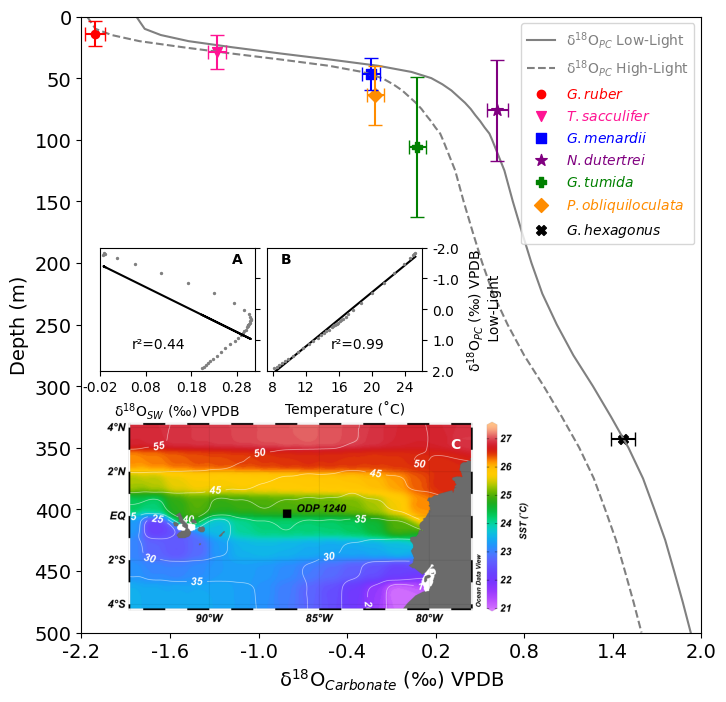

In [58]:
fig, axs = plt.subplots(figsize=(8,8))

axs.plot(d18Ocarb_VPDB,woa2018['depth_m'],color='grey',label='\u03b4$^{18}$O$_{PC}$ Low-Light')
axs.plot(d18Ocarb_VPDB_hilight,woa2018['depth_m'],ls='--',color='grey',label='\u03b4$^{18}$O$_{PC}$ High-Light')

pena_err = 0.07
rippert_err = 0.08
pallone_err = 0.06

# axs.scatter(d18Ocarb_VPDB,woa2018['depth_m'],s=2,color='black')

axs.set_ylabel('Depth (m)', fontsize=14)
axs.set_ylim(0,500)
axs.invert_yaxis()
axs.invert_xaxis()

y_ticks = np.arange(0,505,50)
axs.set_yticks(y_ticks)
axs.set_yticklabels(y_ticks,fontsize=14)

axs.set_xlim(-2.2,2)
x_ticks = np.round(np.arange(-2.2,2.1,0.6),2)
axs.set_xticks(x_ticks)
axs.set_xticklabels(x_ticks,fontsize=14)
axs.set_xlabel('\u03b4$^{18}$O$_{Carbonate}$ (\u2030) VPDB', size=14);

axs.scatter(ruber_d18O, ruber_depth, color='red', label='$G. ruber$')
axs.errorbar(ruber_d18O, ruber_depth, xerr=pena_err, yerr=ruber_err, color='red',capsize=5)

axs.scatter(sacc_d18O, sacc_depth, color='deeppink', label='$T. sacculifer$', marker="v",s=50)
axs.errorbar(sacc_d18O, sacc_depth,xerr=pallone_err,yerr=sacc_err, color='deeppink',capsize=5)

axs.scatter(men_d18O, men_depth, color='blue', label='$G. menardii$', marker="s",s=50)
axs.errorbar(men_d18O, men_depth,xerr=pallone_err,yerr=men_err, color='blue',capsize=5)

axs.scatter(tum_d18O, tum_depth, color='green', label='$G. tumida$', marker="P",s=50)
axs.errorbar(tum_d18O, tum_depth,xerr=pallone_err,yerr=tum_err, color='green',capsize=5)

axs.scatter(dut_d18O, dut_depth, color='purple', label='$N. dutertrei$', marker="*",s=75)
axs.errorbar(dut_d18O, dut_depth,xerr=pena_err,yerr=dut_err, color='purple',capsize=5)

axs.scatter(obliq_d18O, obliq_depth, color='darkorange', label='$P. obliquiloculata$', marker="D",s=50)
axs.errorbar(obliq_d18O, obliq_depth,xerr=pallone_err,yerr=obliq_err, color='darkorange',capsize=5)

axs.scatter(hex_d18O, hex_depth, color='black',label='$G. hexagonus$', marker="X",s=50)
axs.errorbar(hex_d18O, hex_depth,xerr=rippert_err, color='black',capsize=5)


custom_legend_labels = [
    plt.Line2D([],[], color='grey',label='\u03b4$^{18}$O$_{PC}$ Low-Light'),
    plt.Line2D([],[], color='grey',ls= '--', label='\u03b4$^{18}$O$_{PC}$ High-Light'),
    plt.scatter([], [], color='red', label='$G. ruber$'),
    plt.scatter([], [], color='deeppink', label='$T. sacculifer$', marker="v",s=50),
    plt.scatter([], [], color='blue', label='$G. menardii$', marker="s",s=50),
    plt.scatter([], [], color='purple', label='$N. dutertrei$', marker="*",s=75),
    plt.scatter([], [], color='green', label='$G. tumida$', marker="P",s=50),
    plt.scatter([], [], color='darkorange', label='$P. obliquiloculata$', marker="D",s=50),
    plt.scatter([], [], color='black', label='$G. hexagonus$', marker="X",s=50)]

legend = axs.legend(handles=custom_legend_labels,loc='upper right')

legend.get_texts()[0].set_color('grey')
legend.get_texts()[1].set_color('grey')
legend.get_texts()[2].set_color('red')
legend.get_texts()[3].set_color('deeppink')
legend.get_texts()[4].set_color('blue')
legend.get_texts()[5].set_color('purple')
legend.get_texts()[6].set_color('green')
legend.get_texts()[7].set_color('darkorange')
legend.get_texts()[8].set_color('black')

axin1 = axs.inset_axes([0.03, 0.425, 0.25, 0.2])

axin1.scatter(d18Osw_VPDB[0:37],d18Ocarb_VPDB[0:37],color='grey',s=2)
axin1.plot(d18Osw_VPDB[0:37],ynew3,color='black')
axin1.text(0.05,1.25, string3a,fontsize=10)
axin1.text(0.27,-1.5, 'A',fontsize=10,weight='bold')
axin1.set_xlabel('\u03b4$^{18}$O$_{SW}$ (\u2030) VPDB',color='black',fontsize=10)

yticks = np.arange(-2,2.1,1)
xticks = np.round(np.arange(-0.02,0.33,0.1),2)
axin1.set_ylim(-2,2)
axin1.set_yticks(yticks)
axin1.yaxis.tick_right()
axin1.set_yticklabels([])
axin1.invert_yaxis()
axin1.set_xlim(-0.02,0.32)
axin1.set_xticks(xticks)
axin1.set_xticklabels(xticks,fontsize=10)


axin2 = axs.inset_axes([0.3, 0.425, 0.25, 0.2])
axin2.scatter(woa2018['temperature_degC'][0:37],d18Ocarb_VPDB[0:37],color='grey',s=2,zorder=2)
axin2.plot(woa2018['temperature_degC'][0:37],ynew4,color='black',zorder=1)
axin2.text(15,1.25, string4a,fontsize=10)
axin2.set_ylim(-2,2)
axin2.invert_yaxis()
axin2.text(9,-1.5,'B',fontsize=10,weight='bold')
axin2.set_xlabel('Temperature (˚C)',fontsize=10)
axin2.set_yticks(yticks)
axin2.set_yticklabels(yticks)
xticks=np.round(np.arange(8,28,4),2)
axin2.set_xticks(xticks)
axin2.set_xticklabels(xticks,fontsize=10)
axin2.set_ylabel('\u03b4$^{18}$O$_{PC}$ (\u2030) VPDB \n Low-Light', color='black',rotation=90,fontsize=10)
axin2.yaxis.tick_right()
axin2.yaxis.set_label_position("right")

imagebox = OffsetImage(image, zoom=.05, resample='bilinear')
xy = (-0.6,410)
ab = AnnotationBbox(imagebox, xy, frameon=False)
axs.add_artist(ab)
axs.text(0.3,350, 'C',color='white',fontsize=10,weight='bold')

plt.show()

## Figure 2

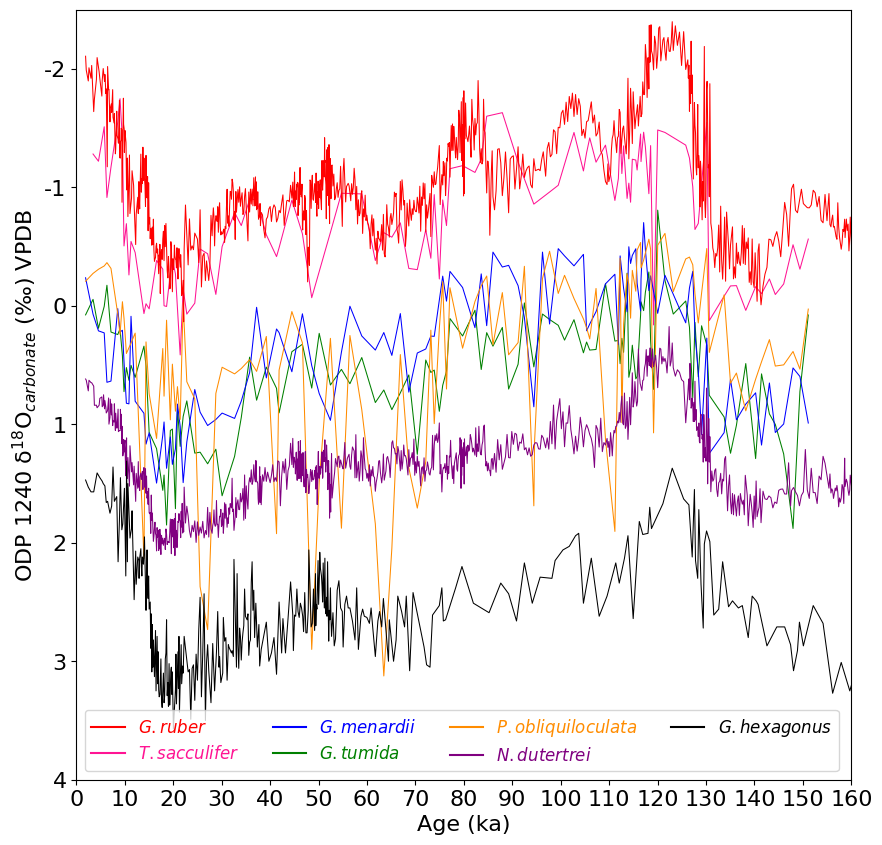

In [59]:
fig, axs = plt.subplots(figsize=(10,10))

axs.plot(sacc['age_ka'],sacc['d18O'], label='$T. sacculifer$',color='deeppink', lw=0.75)
axs.plot(tum['age_ka'],tum['d18O'], label='$G. tumida$',color='green', lw=0.75)
axs.plot(menardii['age_ka'],menardii['d18O'], label='$G. menardii$',color='blue', lw=0.75)
axs.plot(obliq['age_ka'],obliq['d18O'], label='$P. obliquiloculata$',color='darkorange', lw=0.75)
axs.plot(pena2008_ruber_18O['age_ka'],pena2008_ruber_18O['G. ruber δ18O (‰) VPDB'],color='red', label = '$G. ruber$', lw=0.75)
axs.plot(pena2008_duter_18O['age_ka'],pena2008_duter_18O['N. dutertrei δ18O (‰) VPDB'],color='purple',label = '$N. dutertrei$',lw=0.75)
axs.plot(ripert2017_hex['age_ka'],ripert2017_hex['G. hexagonus δ18O (‰) VPDB'],color='black',label = '$G. hexagonus$', lw=0.75)

axs.invert_yaxis()
axs.set_xlim(0,160)
xticks = np.arange(0,165,10)
axs.set_xticks(xticks)
axs.set_xticklabels(xticks, fontsize=16)

axs.set_ylim(4,-2.5)
yticks = np.arange(-2,4.1, 1)
axs.set_yticks(yticks)
axs.set_yticklabels(yticks.astype(int), fontsize=16)

axs.set_ylabel('ODP 1240 \u03b4$^{18}$O$_{carbonate}$ (\u2030) VPDB', size=16)
axs.set_xlabel('Age (ka)', size=16)

handles, labels = axs.get_legend_handles_labels()


custom_legend_labels = [
    plt.Line2D([], [], color='red', label='$G. ruber$'),
    plt.Line2D([], [], color='deeppink', label='$T. sacculifer$'),
    plt.Line2D([], [], color='blue', label='$G. menardii$'),
    plt.Line2D([], [], color='green', label='$G. tumida$'),
    plt.Line2D([], [], color='darkorange', label='$P. obliquiloculata$'),
    plt.Line2D([], [], color='purple', label='$N. dutertrei$'),
    plt.Line2D([], [], color='black', label='$G. hexagonus$')]

legend = axs.legend(handles=custom_legend_labels,prop={'size': 12},ncol=4)

legend.get_texts()[0].set_color('red')
legend.get_texts()[1].set_color('deeppink')
legend.get_texts()[2].set_color('blue')
legend.get_texts()[3].set_color('green')
legend.get_texts()[4].set_color('darkorange')
legend.get_texts()[5].set_color('purple')
legend.get_texts()[6].set_color('black')

plt.show()

## Figure 3

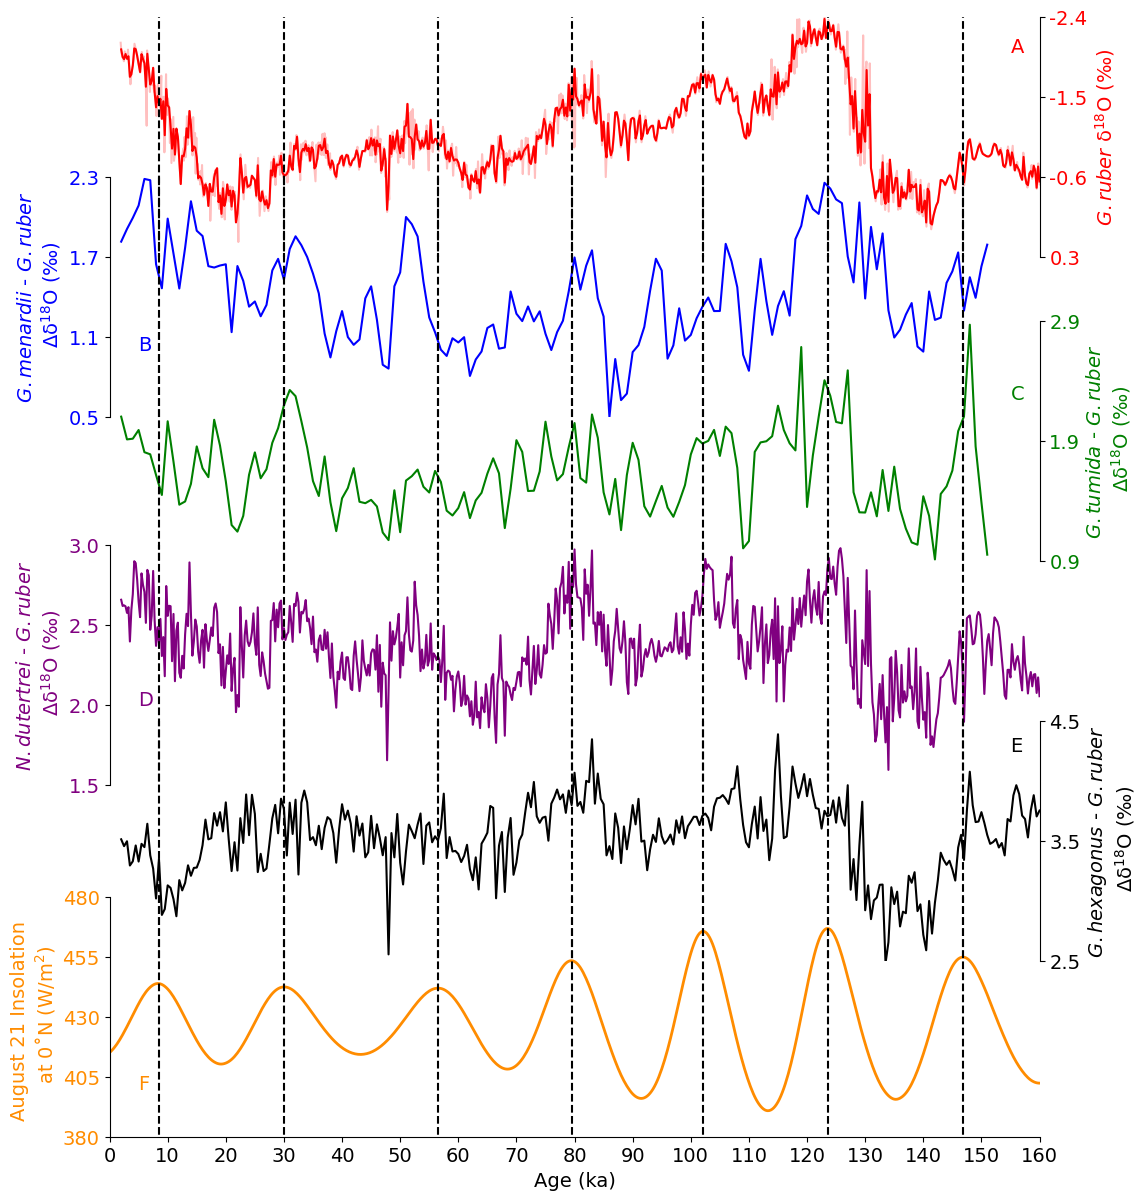

In [60]:
fig = plt.figure(constrained_layout=True, figsize=(12,16))
gs = gridspec.GridSpec(8,1)
plt.subplots_adjust(wspace=None, hspace=-.3)

ax1 = fig.add_subplot(gs[0,0])
ax1.set_position([0.125, 0.9, 0.775, 0.15]) 
ax1.set_facecolor('#FFFFFF00')
ax1.set_xlim(0,160)
ax1.set_xticks([])
ax1.plot(resampled_ruber['age_ka'],resampled_ruber['ruber_d18O'],color='red')
ax1.plot(pena2008_ruber_18O['age_ka'],pena2008_ruber_18O['G. ruber δ18O (‰) VPDB'],color='red', alpha=0.25)
ax1.set_ylim(-2.4,0.3)
ax1.invert_yaxis()
ax1.set_ylabel('$G. ruber$ \u03b4$^{18}$O (\u2030)',size=14,color='red')
ax1.text(155,-2,'A',size=14,color='red')

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(True)
ax1.spines['bottom'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.yaxis.set_label_position("right")
ax1.yaxis.tick_right()
yticks = np.round(np.arange(-2.4,0.4,0.9),2)
ax1.set_yticks(yticks)
ax1.set_yticklabels(yticks,size=14,color='red')

y = np.arange(-400,500)
x1 = np.zeros(len(y))+ 8.5
x2 = np.zeros(len(y))+ 30
x3 = np.zeros(len(y))+ 56.5
x4 = np.zeros(len(y))+ 79.5
x5 = np.zeros(len(y))+ 102.125
x6 = np.zeros(len(y))+ 123.6
x7 = np.zeros(len(y))+ 146.75

ax2 = fig.add_subplot(gs[1,0])

ax2.set_position([0.125, 0.8, 0.775, 0.15]) 

ax2.set_facecolor('#FFFFFF00')
ax2.set_xlim(0,160)
ax2.set_xticks([])
ax2.plot(dif_men['age_ka'],dif_men['dif'],color='blue')

ax2.set_ylim(0.5,2.3)
ax2.set_ylabel('$G. menardii$ - $G. ruber$ \n \u0394\u03b4$^{18}$O (\u2030)',size=14,color='blue')
yticks = np.round(np.arange(0.5,2.4,0.6),2)
ax2.set_yticks(yticks)
ax2.set_yticklabels(yticks,size=14,color='blue')
ax2.yaxis.tick_left()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(True)
ax2.yaxis.set_label_position("left")
ax2.text(5,1,'B',size=14,color='blue')

ax2b = fig.add_subplot(gs[2,0])

ax2b.set_position([0.125, 0.71, 0.775, 0.15]) 

ax2b.set_facecolor('#FFFFFF00')
ax2b.set_xlim(0,160)
ax2b.set_xticks([])
ax2b.plot(dif_tum['age_ka'],dif_tum['dif'],color='green')
ax2b.set_ylabel('$G. tumida$ - $G. ruber$ \n \u0394\u03b4$^{18}$O (\u2030)',size=14,color='green')
ax2b.spines['top'].set_visible(False)
ax2b.spines['right'].set_visible(True)
ax2b.spines['bottom'].set_visible(False)
ax2b.spines['left'].set_visible(False)
ax2b.set_ylim(0.9,2.9)
yticks = np.round(np.arange(0.9,3,1),2)
ax2b.set_yticks(yticks)
ax2b.set_yticklabels(yticks,size=14,color='green')
ax2b.yaxis.tick_right()
ax2b.yaxis.set_label_position("right")
ax2b.text(155,2.25,'C',size=14,color='green')

ax3 = fig.add_subplot(gs[3,0])

ax3.set_position([0.125, 0.57, 0.775, 0.15]) 

ax3.set_xticks([])
ax3.set_facecolor('#FFFFFF00')
ax3.set_xlim(0,160)
ax3.plot(dif_dut['age_ka'],dif_dut['dif'],color='purple')
ax3.set_ylim(1.5,3)
ax3.set_ylabel('$N. dutertrei$ - $G. ruber$ \n \u0394\u03b4$^{18}$O (\u2030)',size=14,color='purple')

yticks = np.round(np.arange(1.5,3.1,0.5),1)
ax3.set_yticks(yticks)
ax3.set_yticklabels(yticks,size=14,color='purple')
ax3.yaxis.tick_left()
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['bottom'].set_visible(False)
ax3.spines['left'].set_visible(True)
ax3.yaxis.set_label_position("left")
ax3.text(5,2,'D',size=14,color='purple')

ax4 = fig.add_subplot(gs[4,0])
ax4.set_position([0.125, 0.46, 0.775, 0.15]) 

ax4.set_xticks([])
ax4.set_facecolor('#FFFFFF00')
ax4.set_xlim(0,160)
ax4.plot(dif_hex['age_ka'],dif_hex['dif'],color='black')
ax4.set_ylim(2.5,4.5)
ax4.set_ylabel('$G. hexagonus$ - $G. ruber$ \n \u0394\u03b4$^{18}$O (\u2030)',size=14,color='black')

yticks = np.round(np.arange(2.5,4.6,1),2)
ax4.set_yticks(yticks)
ax4.set_yticklabels(yticks,size=14)
ax4.yaxis.tick_right()
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(True)
ax4.spines['bottom'].set_visible(False)
ax4.spines['left'].set_visible(False)
ax4.yaxis.set_label_position("right")
ax4.text(155,4.25,'E',size=14)

ax5 = fig.add_subplot(gs[5,0])

ax5.set_position([0.125, 0.35, 0.775, 0.15]) 

ax5.set_facecolor('#FFFFFF00')
ax5.set_xlim(0,160)
ax5.plot(august['age_ka'],august['insol_aug_0_wm2'],color='darkorange',lw=2)
ax5.set_ylim(380,480)
ax5.set_ylabel('August 21 Insolation \n at 0˚N (W/m$^{2}$)',fontsize=14, color='darkorange')

yticks = np.round(np.arange(380,481,25),0)
ax5.set_yticks(yticks)
ax5.set_yticklabels(yticks,size=14, color='darkorange')
ax5.yaxis.tick_left()
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.spines['bottom'].set_visible(True)
ax5.spines['left'].set_visible(True)
ax5.yaxis.set_label_position("left")
ax5.text(5, 400, 'F', size=14, color='darkorange')
ax5.set_xlabel('Age (ka)', fontsize=14)
xticks = np.arange(0,165,10)
ax5.set_xticks(xticks)
ax5.set_xticklabels(xticks, fontsize=14);


## Add lines at August 21 insolation maxima 

ax1.plot(x1,y,ls='--',color='black')
ax1.plot(x2,y,ls='--',color='black')
ax1.plot(x3,y,ls='--',color='black')
ax1.plot(x4,y,ls='--',color='black')
ax1.plot(x5,y,ls='--',color='black')
ax1.plot(x6,y,ls='--',color='black')
ax1.plot(x7,y,ls='--',color='black')

ax2.plot(x1,y,ls='--',color='black')
ax2.plot(x2,y,ls='--',color='black')
ax2.plot(x3,y,ls='--',color='black')
ax2.plot(x4,y,ls='--',color='black')
ax2.plot(x5,y,ls='--',color='black')
ax2.plot(x6,y,ls='--',color='black')
ax2.plot(x7,y,ls='--',color='black')

ax2b.plot(x1,y,ls='--',color='black')
ax2b.plot(x2,y,ls='--',color='black')
ax2b.plot(x3,y,ls='--',color='black')
ax2b.plot(x4,y,ls='--',color='black')
ax2b.plot(x5,y,ls='--',color='black')
ax2b.plot(x6,y,ls='--',color='black')
ax2b.plot(x7,y,ls='--',color='black')

ax3.plot(x1,y,ls='--',color='black')
ax3.plot(x2,y,ls='--',color='black')
ax3.plot(x3,y,ls='--',color='black')
ax3.plot(x4,y,ls='--',color='black')
ax3.plot(x5,y,ls='--',color='black')
ax3.plot(x6,y,ls='--',color='black')
ax3.plot(x7,y,ls='--',color='black')

ax4.plot(x1,y,ls='--',color='black')
ax4.plot(x2,y,ls='--',color='black')
ax4.plot(x3,y,ls='--',color='black')
ax4.plot(x4,y,ls='--',color='black')
ax4.plot(x5,y,ls='--',color='black')
ax4.plot(x6,y,ls='--',color='black')
ax4.plot(x7,y,ls='--',color='black')

ax5.plot(x1,y,ls='--',color='black')
ax5.plot(x2,y,ls='--',color='black')
ax5.plot(x3,y,ls='--',color='black')
ax5.plot(x4,y,ls='--',color='black')
ax5.plot(x5,y,ls='--',color='black')
ax5.plot(x6,y,ls='--',color='black')
ax5.plot(x7,y,ls='--',color='black')

plt.show()

## Figure 4

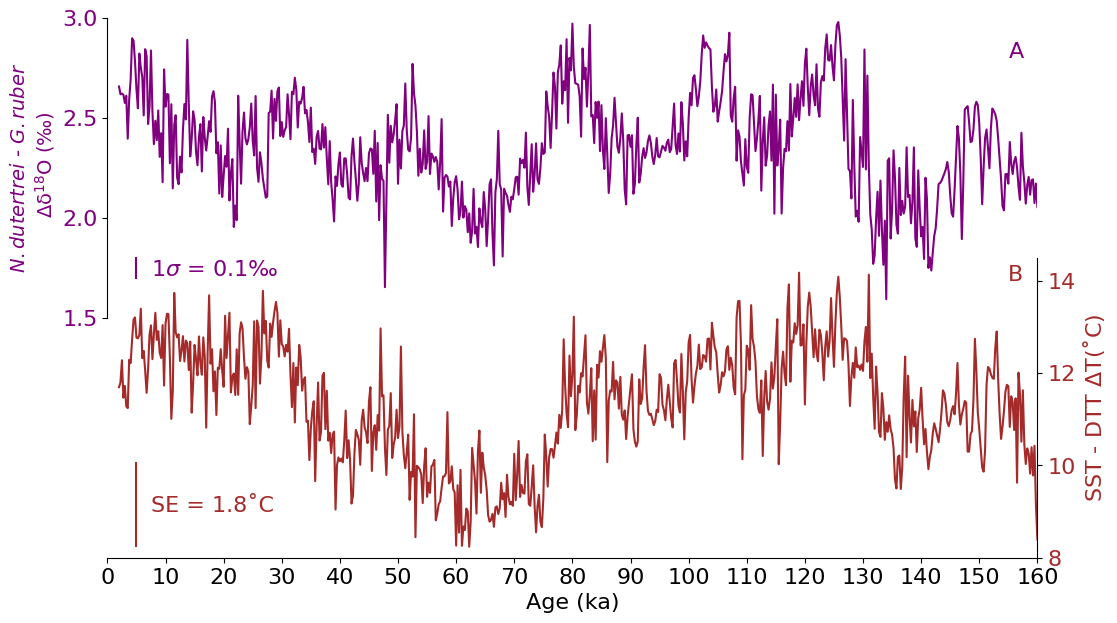

In [61]:
fig = plt.figure(constrained_layout=True, figsize=(12,6))
gs = gridspec.GridSpec(3,1)

ax1 = fig.add_subplot(gs[0,0])

ax1.set_position([0.125, 0.9, 0.775, 0.5]) 

ax1.set_xticks([])
ax1.set_facecolor('#FFFFFF00')
ax1.set_xlim(0,160)
ax1.plot(dif_dut['age_ka'],dif_dut['dif'],color='purple')
ax1.set_ylim(1.5,3)
ax1.set_ylabel('$N. dutertrei$ - $G. ruber$ \n \u0394\u03b4$^{18}$O (\u2030)',size=14,color='purple')

yticks = np.round(np.arange(1.5,3.1,0.5),1)
ax1.set_yticks(yticks)
ax1.set_yticklabels(yticks,size=16,color='purple')
ax1.yaxis.tick_left()
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.spines['left'].set_visible(True)
ax1.yaxis.set_label_position("left")
ax1.text(155,2.8,'A',color='purple',size=16)

x = np.zeros(2) + 5
y = [1.7, 1.8]

ax1.plot(x,y,color='purple')
ax1.text(x[0]+2.5, 1.71, '1$\sigma$ = 0.1\u2030',size=16, color='purple')


ax2 = fig.add_subplot(gs[1,0])

ax2.set_position([0.125, 0.5, 0.775, 0.5]) 

x = np.zeros(2) + 5
y = [8.25, 8.25+1.8]

xticks = np.arange(0,161,10)
ax2.set_xticks(xticks)
ax2.set_xticklabels(xticks,size=16)
ax2.set_facecolor('#FFFFFF00')
ax2.set_xlim(0,160)
ax2.plot(dif_dut_mgca['age_ka'],dif_dut_mgca['dif'],color='brown')
ax2.plot(x,y, color='brown')
ax2.text(x[0]+2.5, 9, 'SE = 1.8˚C',size=16,color='brown')
ax2.set_ylim(8,14.5)
ax2.set_ylabel('SST - DTT $\Delta$T(˚C)',size=16,color='brown')
ax2.set_xlabel('Age (ka)',size=16)
yticks = np.round(np.arange(8,15,2),0)
ax2.set_yticks(yticks)
ax2.set_yticklabels(yticks,size=16,color='brown')
ax2.yaxis.tick_right()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(True)
ax2.spines['bottom'].set_visible(True)
ax2.spines['left'].set_visible(False)
ax2.yaxis.set_label_position("right")
ax2.text(155,14,'B',color='brown',size=16)

plt.show()

## Figure 5

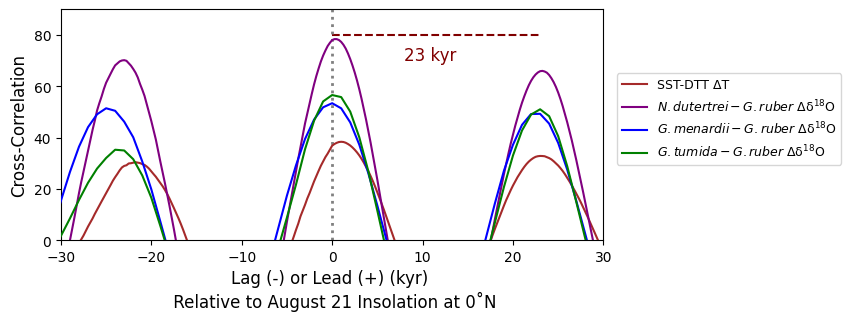

In [62]:
plt.figure(figsize=(7,3))
plt.plot(lags_mgca_dut, cross_corr_mgca_dut,color='brown',label='SST-DTT \u0394T',zorder=10)
plt.plot(lags_dut_rub, cross_corr_dut_rub,color='purple',label='$N. dutertrei - G. ruber$ \u0394\u03b4$^{18}$O',zorder=10)
plt.plot(lags_men_rub, cross_corr_men_rub,color='blue',label='$G. menardii - G. ruber$ \u0394\u03b4$^{18}$O',zorder=10)
plt.plot(lags_tum_rub, cross_corr_tum_rub,color='green',label='$G. tumida - G. ruber$ \u0394\u03b4$^{18}$O',zorder=10)

plt.xlabel('Lag (-) or Lead (+) (kyr) \n Relative to August 21 Insolation at 0˚N',fontsize=12)
plt.ylabel('Cross-Correlation',fontsize=12)
plt.xlim(-30,30)
plt.ylim(0,90)

plt.legend(loc='upper right', bbox_to_anchor=(1.45,0.75),ncol=1,prop={'size':9})

x = np.arange(0,24,1)
y = x*0 + 80

plt.plot(x,y,color='maroon',ls='--')
plt.text(8,70,'23 kyr',color='maroon',fontsize=12)
plt.axvline(x=0, color='grey', linestyle=':',lw=2)

plt.show()

## Supplemental Figures

## Supplementary Figure 1

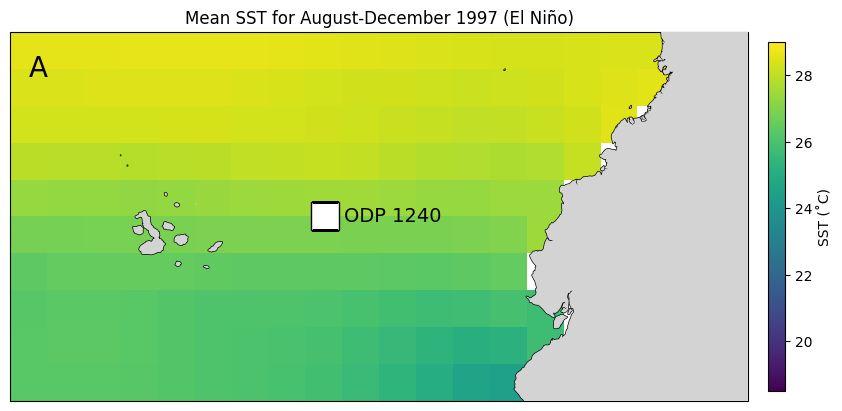

In [63]:
sst_data = data_sst['sst']
lat_min, lat_max = -5, 5
lon_min, lon_max = 265, 285
years = [1997]
months = [8,9,10,11,12] 

subset_data = sst_data.sel(lat=slice(lat_max, lat_min),lon=slice(lon_min, lon_max))
t_filtered_data = subset_data.sel(time=subset_data['time.year'].isin(years) & subset_data['time.month'].isin(months))
mean_data = t_filtered_data.mean(dim='time')

lat = subset_data['lat']
lon = subset_data['lon']

plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

vmin = 18.5
vmax = 29

mesh = plt.pcolormesh(lon, lat, mean_data, transform=ccrs.PlateCarree(), cmap='viridis', shading='auto',vmin=vmin, vmax=vmax)

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, facecolor='lightgrey',zorder=3)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.set_title('Mean SST for August-December 1997 (El Niño)')
cbar = plt.colorbar(mesh, orientation='vertical', pad=0.025, fraction=0.0225)
cbar.set_label('SST (˚C)')

point_lon = 273.54
point_lat = 0.02
ax.plot(point_lon, point_lat, marker='s',markeredgecolor='black', color='white',markersize=20, transform=ccrs.PlateCarree(), label="ODP 1240")
ax.text(point_lon + 0.5, point_lat, "ODP 1240", color="black", fontsize=14, transform=ccrs.PlateCarree(), ha='left', va='center')
ax.text(265 + 0.5, 4, "A", color="black", fontsize=20,transform=ccrs.PlateCarree(), ha='left', va='center')

plt.show()

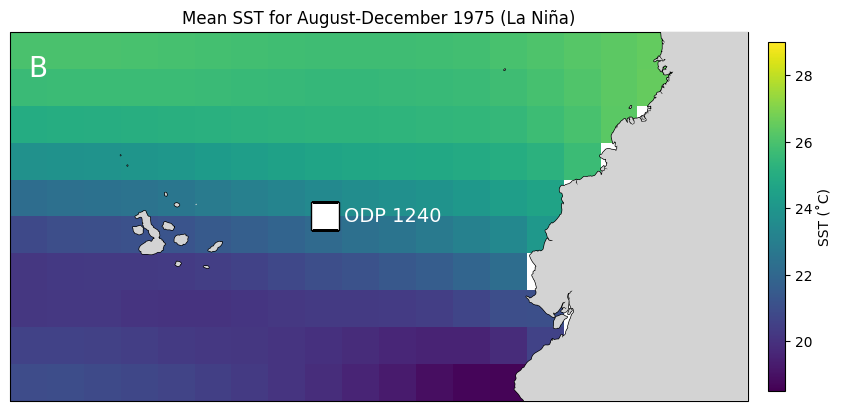

In [64]:
sst_data = data_sst['sst']
lat_min, lat_max = -5, 5
lon_min, lon_max = 265, 285
years = [1975]
months = [8,9,10,11,12] 

subset_data = sst_data.sel(lat=slice(lat_max, lat_min),lon=slice(lon_min, lon_max))
t_filtered_data = subset_data.sel(time=subset_data['time.year'].isin(years) & subset_data['time.month'].isin(months))
mean_data = t_filtered_data.mean(dim='time')

lat = subset_data['lat']
lon = subset_data['lon']

plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

vmin = 18.5
vmax = 29

mesh = plt.pcolormesh(lon, lat, mean_data, transform=ccrs.PlateCarree(), cmap='viridis', shading='auto',vmin=vmin, vmax=vmax)

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, facecolor='lightgrey',zorder=3)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.set_title('Mean SST for August-December 1975 (La Niña)')
cbar = plt.colorbar(mesh, orientation='vertical', pad=0.025, fraction=0.0225)
cbar.set_label('SST (˚C)')

point_lon = 273.54
point_lat = 0.02
ax.plot(point_lon, point_lat, marker='s',markeredgecolor='black', color='white',markersize=20, transform=ccrs.PlateCarree(), label="ODP 1240")
ax.text(point_lon + 0.5, point_lat, "ODP 1240", color="white", fontsize=14, transform=ccrs.PlateCarree(), ha='left', va='center')
ax.text(265 + 0.5, 4, "B", color="white", fontsize=20,transform=ccrs.PlateCarree(), ha='left', va='center')

plt.show()

## Supplementary Figure 2

Text(0.5, 0, 'Frequency (1/kyr)')

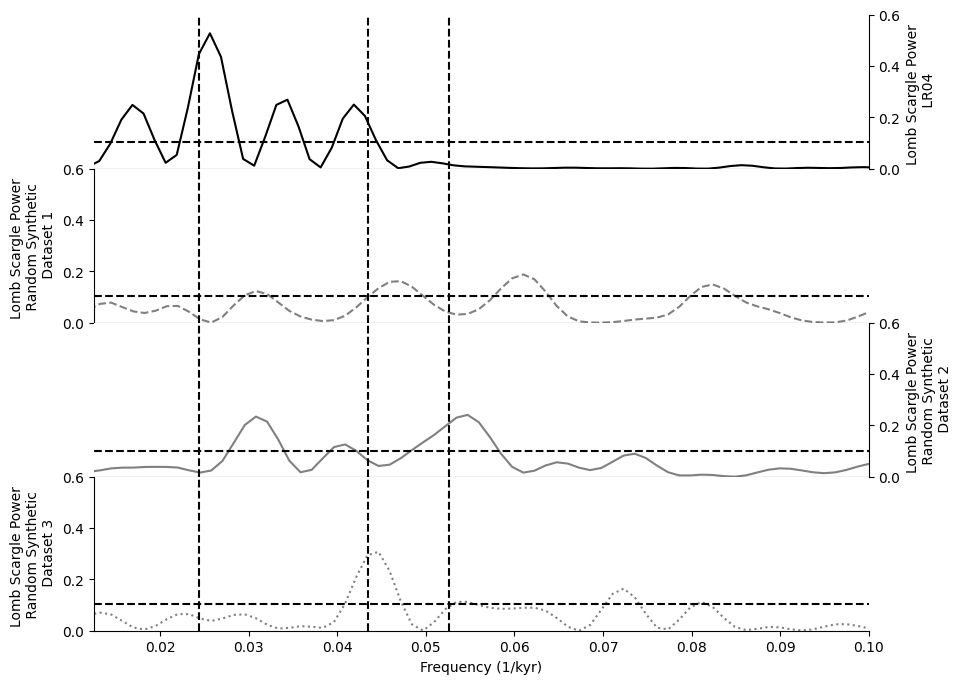

In [65]:
fig = plt.figure(constrained_layout=True, figsize=(10,10))
gs = gridspec.GridSpec(5,1)
gs.update(hspace=0)

ax2 = fig.add_subplot(gs[0,0])
ax2.plot(frequency11, power11, color='black')
ax2.plot(np.arange(0.01,0.11,0.01), np.zeros(10)+fa11,color='black',label='False Alarm Probability 5%',ls='--')
ax2.set_ylim(0,0.6)
ax2.set_xlim(1/80,1/10)

ax2.plot(np.zeros(5)+1/41, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')
ax2.plot(np.zeros(5)+1/23, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')
ax2.plot(np.zeros(5)+1/19, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')

ax2.set_ylabel('Lomb Scargle Power \n LR04',color='black')
ax2.yaxis.tick_right()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(True)
ax2.spines['bottom'].set_visible(True)
ax2.spines['left'].set_visible(False)
ax2.yaxis.set_label_position("right")
ax2.set_xlabel('Frequency (1/kyr)')
ax2.set_xticks([])


ax2 = fig.add_subplot(gs[1,0])
ax2.plot(frequency8, power8, color='grey',ls='--')
ax2.plot(np.arange(0.01,0.11,0.01), np.zeros(10)+fa8,color='black',label='False Alarm Probability 5%',ls='--')
ax2.set_ylim(0,0.6)
ax2.set_xlim(1/80,1/10)

ax2.plot(np.zeros(5)+1/41, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')
ax2.plot(np.zeros(5)+1/23, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')
ax2.plot(np.zeros(5)+1/19, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')

ax2.set_ylabel('Lomb Scargle Power \n Random Synthetic \n Dataset 1',color='black')
ax2.yaxis.tick_left()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(True)
ax2.spines['left'].set_visible(True)
ax2.yaxis.set_label_position("left")
ax2.set_xlabel('Frequency (1/kyr)')
ax2.set_xticks([])


ax2 = fig.add_subplot(gs[2,0])
ax2.plot(frequency9, power9, color='grey',ls='-')
ax2.plot(np.arange(0.01,0.11,0.01), np.zeros(10)+fa9,color='black',label='False Alarm Probability 5%',ls='--')
ax2.set_ylim(0,0.6)
ax2.set_xlim(1/80,1/10)

ax2.plot(np.zeros(5)+1/41, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')
ax2.plot(np.zeros(5)+1/23, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')
ax2.plot(np.zeros(5)+1/19, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')

ax2.set_ylabel('Lomb Scargle Power \n Random Synthetic \n Dataset 2',color='black')
ax2.yaxis.tick_right()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(True)
ax2.spines['bottom'].set_visible(True)
ax2.spines['left'].set_visible(False)
ax2.yaxis.set_label_position("right")
ax2.set_xlabel('Frequency (1/kyr)')
ax2.set_xticks([])

ax2 = fig.add_subplot(gs[3,0])
ax2.plot(frequency10, power10, color='grey',ls=':')
ax2.plot(np.arange(0.01,0.11,0.01), np.zeros(10)+fa10,color='black',label='False Alarm Probability 5%',ls='--')
ax2.set_ylim(0,0.6)
ax2.set_xlim(1/80,1/10)

ax2.plot(np.zeros(5)+1/41, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')
ax2.plot(np.zeros(5)+1/23, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')
ax2.plot(np.zeros(5)+1/19, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')

ax2.set_ylabel('Lomb Scargle Power \n Random Synthetic \n Dataset 3',color='black')
ax2.yaxis.tick_left()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(True)
ax2.spines['left'].set_visible(True)
ax2.yaxis.set_label_position("left")
ax2.set_xlabel('Frequency (1/kyr)')

# plt.show()

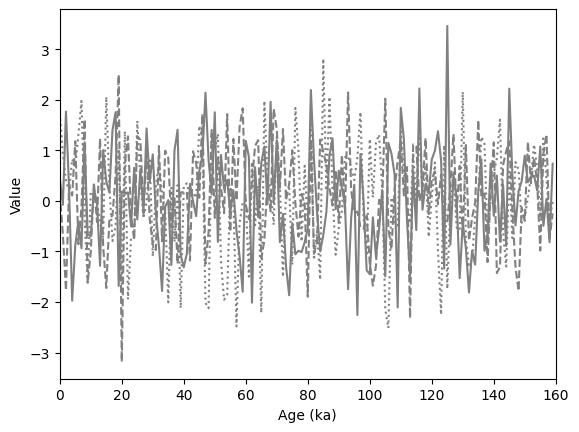

In [66]:
plt.plot(random1['age_ka'],random1['value'],color='grey',label='Random Synthetic Data 1',ls='--')
plt.plot(random2['age_ka'],random2['value'],color='grey',label='Random Synthetic Data 2',ls='-')
plt.plot(random3['age_ka'],random3['value'],color='grey',label='Random Synthetic Data 2',ls=':')
plt.xlim(0,160)
plt.xlabel('Age (ka)')
plt.ylabel('Value')
plt.show()

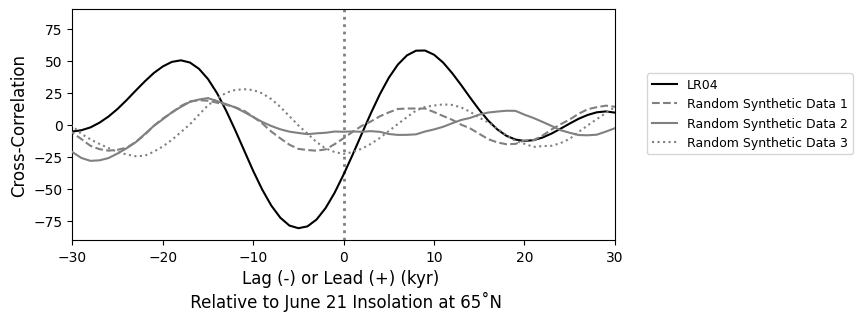

In [67]:
plt.figure(figsize=(7,3))
plt.plot(lags_lr04_june, cross_corr_lr04_june,color='black',label='LR04',zorder=10)
plt.plot(lags_random1_june, cross_corr_random1_june,color='grey',ls='--',label='Random Synthetic Data 1',zorder=10)
plt.plot(lags_random2_june, cross_corr_random2_june,color='grey',ls='-',label='Random Synthetic Data 2',zorder=10)
plt.plot(lags_random3_june, cross_corr_random3_june,color='grey', ls=':',label='Random Synthetic Data 3',zorder=10)

plt.xlabel('Lag (-) or Lead (+) (kyr) \n Relative to June 21 Insolation at 65˚N',fontsize=12)
plt.ylabel('Cross-Correlation',fontsize=12)
plt.xlim(-30,30)
plt.ylim(-90,90)

plt.legend(loc='upper right', bbox_to_anchor=(1.45,0.75),ncol=1,prop={'size':9})
plt.axvline(x=0, color='grey', linestyle=':',lw=2)

plt.show()

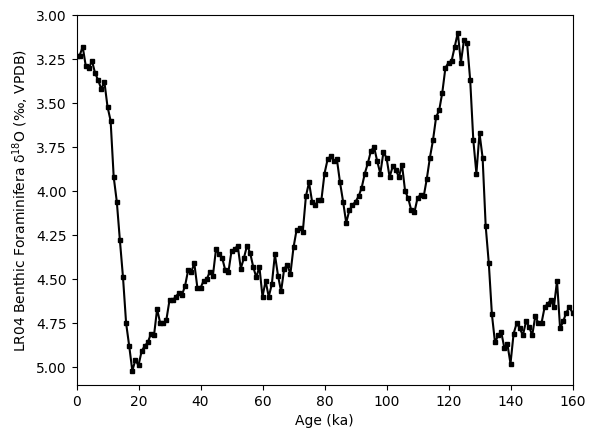

In [68]:
plt.plot(lr04['age_ka'],lr04['benthic_d18O'],color='black',marker='s',markersize=2.5)
plt.xlim(0,160)
plt.xlabel('Age (ka)')
plt.ylabel('LR04 Benthic Foraminifera \u03b4$^{18}$O (\u2030, VPDB)')
plt.ylim(5.1,3)
plt.show()

## Supplementary Figure 3

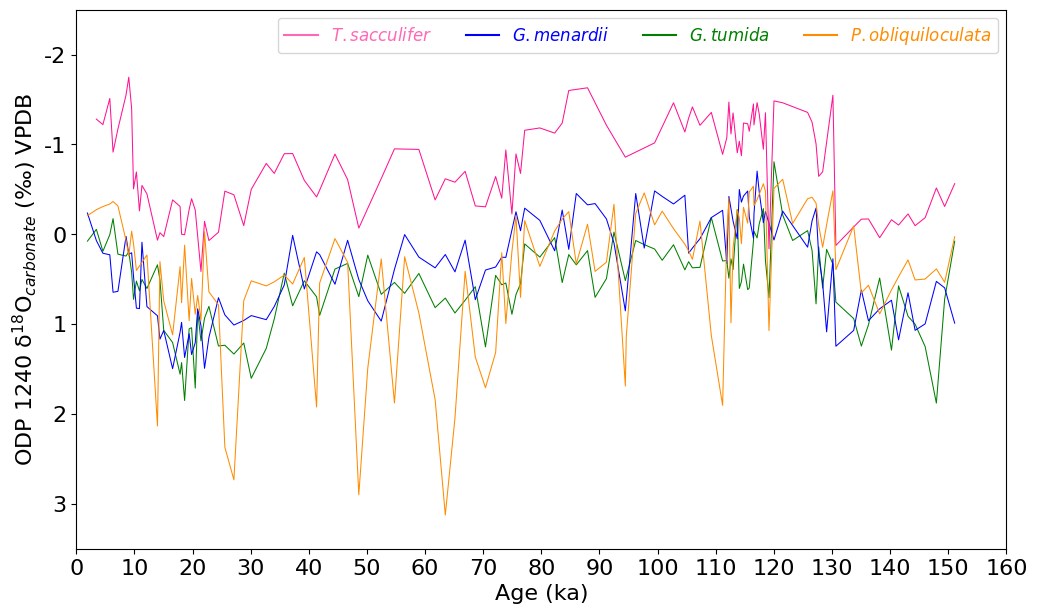

In [69]:
fig, axs = plt.subplots(figsize=(12,7))

axs.plot(tum['age_ka'],tum['d18O'], label='$G. tumida$',color='green', lw=0.75)
axs.plot(menardii['age_ka'],menardii['d18O'], label='$G. menardii$',color='blue', lw=0.75)
axs.plot(sacc['age_ka'],sacc['d18O'], label='$T. sacculifer$',color='deeppink', lw=0.75)
axs.plot(obliq['age_ka'],obliq['d18O'], label='$P. obliquiloculata$',color='darkorange', lw=0.75)

axs.invert_yaxis()
axs.set_xlim(0,160)
xticks = np.arange(0,165,10)
axs.set_xticks(xticks)
axs.set_xticklabels(xticks, fontsize=16)

axs.set_ylim(3.5,-2.5)
yticks = np.arange(-2,3.5, 1)
axs.set_yticks(yticks)
axs.set_yticklabels(yticks.astype(int), fontsize=16)

axs.set_ylabel('ODP 1240 \u03b4$^{18}$O$_{carbonate}$ (\u2030) VPDB', size=16)
axs.set_xlabel('Age (ka)', size=16)

handles, labels = axs.get_legend_handles_labels()

custom_legend_labels = [
    plt.Line2D([], [], color='hotpink', label='$T. sacculifer$'),
    plt.Line2D([], [], color='blue', label='$G. menardii$'),
        plt.Line2D([], [], color='green', label='$G. tumida$'),
    plt.Line2D([], [], color='darkorange', label='$P. obliquiloculata$')]

legend = axs.legend(handles=custom_legend_labels,ncol=4,prop={'size': 12})

legend.get_texts()[0].set_color('hotpink')
legend.get_texts()[1].set_color('blue')
legend.get_texts()[2].set_color('green')
legend.get_texts()[3].set_color('darkorange')

plt.show()

## Supplementary Figure 4

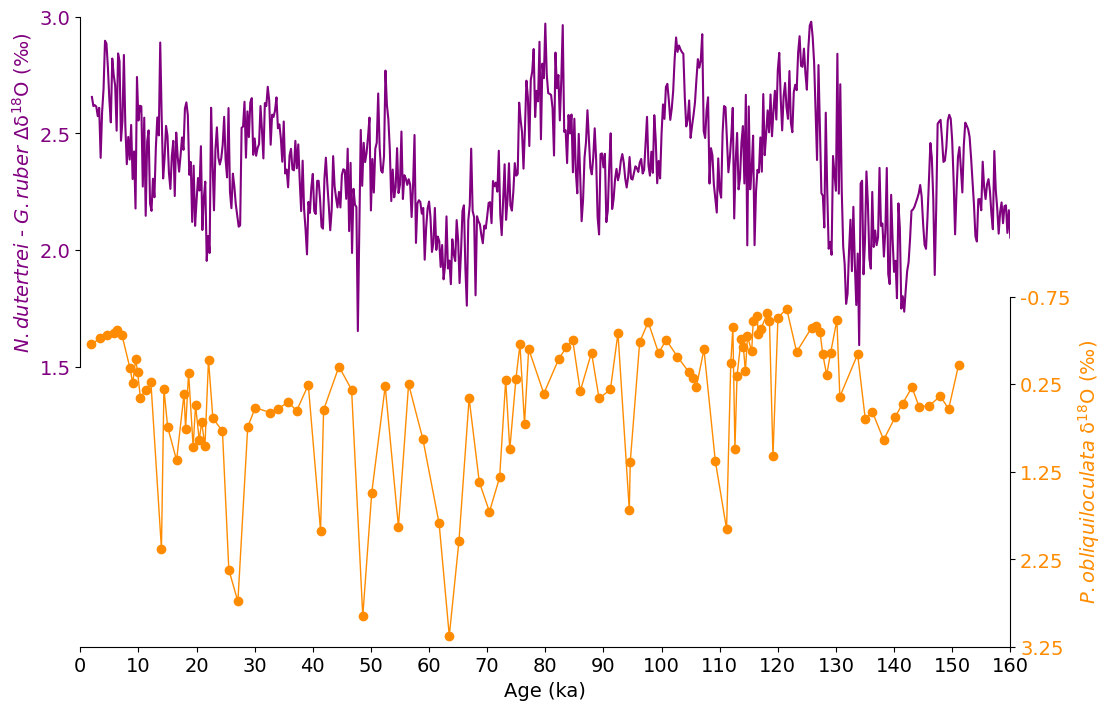

In [70]:
fig = plt.figure(constrained_layout=True, figsize=(12,7))
gs = gridspec.GridSpec(2,1)
plt.subplots_adjust(wspace=None, hspace=-2)

ax3 = fig.add_subplot(gs[0,0])
ax3.set_position([0.125, 1, 0.775, 0.5]) 
ax3.set_facecolor('#FFFFFF00')

ax3.set_xticks([])
ax3.set_facecolor('#FFFFFF00')
ax3.set_xlim(0,160)
ax3.plot(dif_dut['age_ka'],dif_dut['dif'],color='purple')
ax3.set_ylim(1.5,3)
ax3.set_ylabel('$N. dutertrei$ - $G. ruber$ \u0394\u03b4$^{18}$O (\u2030)',size=14,color='purple')

yticks = np.round(np.arange(1.5,3.1,0.5),1)
ax3.set_yticks(yticks)
ax3.set_yticklabels(yticks,size=14,color='purple')
ax3.yaxis.tick_left()
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['bottom'].set_visible(False)
ax3.spines['left'].set_visible(True)
ax3.yaxis.set_label_position("left")

ax4 = fig.add_subplot(gs[1,0])
ax4.set_position([0.125, 0.6, 0.775, 0.5]) 
ax4.set_facecolor('#FFFFFF00')

ax4.plot(obliq['age_ka'],obliq['d18O'], label='P. obliq$',color='darkorange', lw=1)
ax4.scatter(obliq['age_ka'],obliq['d18O'], label='P. obliq$',color='darkorange')
ax4.set_ylabel('$P. obliquiloculata$ \u03b4$^{18}$O (\u2030)',size=14,color='darkorange')

ax4.set_ylim(3.25,-0.75)
ax4.set_xlim(0,160)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(True)
ax4.spines['bottom'].set_visible(True)
ax4.spines['left'].set_visible(False)
ax4.yaxis.set_label_position("right")
ax4.yaxis.tick_right()
yticks = np.round(np.arange(-0.75,3.3),2)
ax4.set_yticks(yticks)
ax4.set_yticklabels(yticks,size=14,color='darkorange')
ax4.set_xlabel('Age (ka)', fontsize=14)
xticks = np.arange(0,165,10)
ax4.set_xticks(xticks)
ax4.set_xticklabels(xticks, fontsize=14);

plt.show()

## Supplementary Figure 5

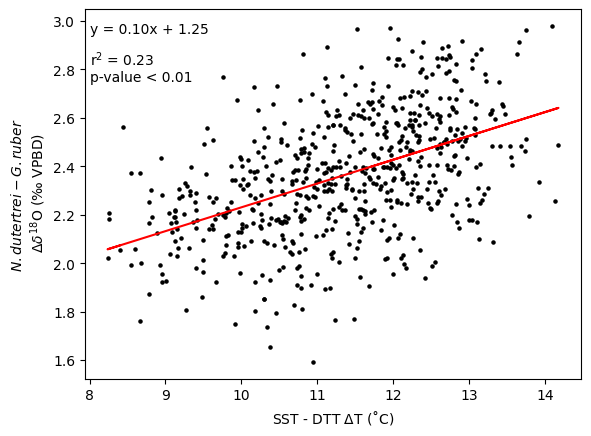

In [71]:
merged_mgca_d18O_dif = pd.merge(dif_dut_mgca, dif_dut, on='age_ka')

plt.scatter(merged_mgca_d18O_dif['dif_x'],merged_mgca_d18O_dif['dif_y'], color='black',s=5)

x = merged_mgca_d18O_dif['dif_x']
y = merged_mgca_d18O_dif['dif_y']

slope, intercept, r_value, p_value, std_err = linregress(x, y)
plt.plot(x, intercept + slope * x, color='red', label='Linear Regression')
plt.ylabel('$N. dutertrei - G. ruber$ \n $\Delta\delta^{18}$O (\u2030 VPBD)')
plt.xlabel('SST - DTT $\Delta$T (˚C)')
plt.text(8 ,2.95 , f'y = {slope:0.2f}x + {intercept:0.2f}')
plt.text(8, 2.75,  f'r$^{2}$ = {r_value**2:0.2f}\np-value < 0.01')
plt.rcParams.update({'font.size': 12})
plt.show()

## Supplementary Figure 6

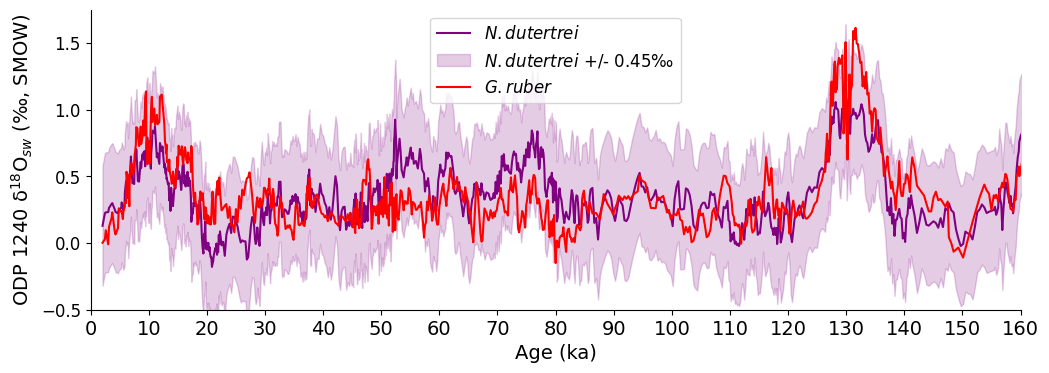

In [72]:
merged_d18Osw_dif = pd.merge(d18Osw_dut, d18Osw_rub, on='age_ka')
merged_d18Osw_dif['dut-rub d18Osw'] = merged_d18Osw_dif['N. dutertrei δ18O seawater average (‰) VPDB'] - merged_d18Osw_dif['G. ruber δ18O seawater average (‰) VPDB']

fig = plt.figure(constrained_layout=True, figsize=(12,12))
gs = gridspec.GridSpec(8,1)
plt.subplots_adjust(wspace=None, hspace=-.3)

ax3 = fig.add_subplot(gs[1,0])

ax3.set_position([0.125, 0.71, 0.775, 0.25]) 
ax3.set_facecolor('#FFFFFF00')
ax3.set_ylabel('ODP 1240 \u03b4$^{18}$O$_{sw}$ (\u2030, SMOW)',size=14,color='black')

ax3.plot(d18Osw_dut['age_ka'],d18Osw_dut['N. dutertrei δ18O seawater average (‰) SMOW'],color='purple',label='$N. dutertrei$')

error = 0.45

ax3.fill_between(d18Osw_dut['age_ka'], d18Osw_dut['N. dutertrei δ18O seawater average (‰) SMOW'] - error, d18Osw_dut['N. dutertrei δ18O seawater average (‰) SMOW'] + error, color='purple', alpha=0.2 , label = '$N. dutertrei$ +/- 0.45‰')

ax3.plot(d18Osw_rub['age_ka'],d18Osw_rub['G. ruber δ18O seawater average (‰) SMOW'],color='red',label='$G. ruber$')


ax3.set_xlim(0,160)
ax3.yaxis.tick_left()
ax3.set_ylim(-0.5,1.75)
yticks = np.round(np.arange(-0.5,1.85,0.5),2)
ax3.set_yticks(yticks)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['bottom'].set_visible(True)
ax3.spines['left'].set_visible(True)
ax3.yaxis.set_label_position("left")
ax3.set_xlabel('Age (ka)', fontsize=14)
xticks = np.arange(0,165,10)
ax3.set_xticks(xticks)
ax3.set_xticklabels(xticks, fontsize=14)
ax3.legend()

plt.show()

## Supplementary Figure 7

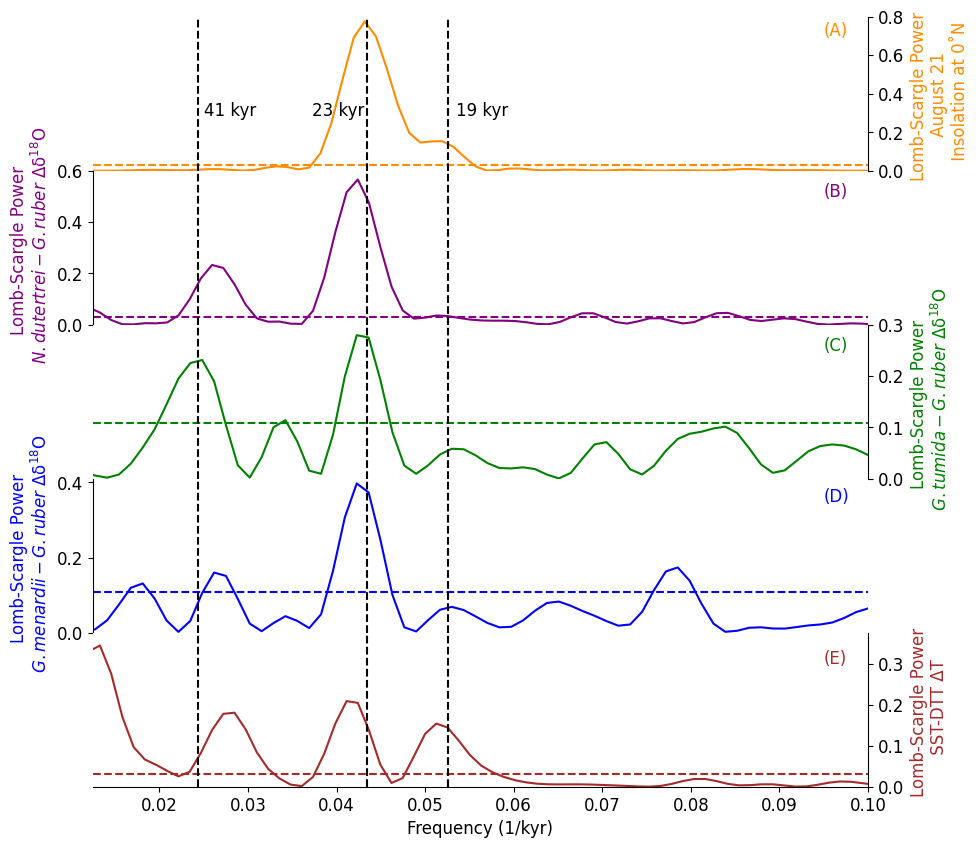

In [73]:
fig = plt.figure(constrained_layout=True, figsize=(10,10))
gs = gridspec.GridSpec(5,1)
gs.update(hspace=0)

ax1 = fig.add_subplot(gs[0,0])
ax1.plot(frequency1, power1, color='darkorange')
ax1.plot(np.arange(0.01,0.11,0.01), np.zeros(10)+fa1,color='darkorange',label='False Alarm Probability 5%',ls='--')
ax1.set_ylim(0,0.8)
ax1.set_xlim(1/80,1/10)
ax1.set_xticks([])
ax1.set_ylabel('Lomb-Scargle Power \n August 21 \n Insolation at 0˚N',color='darkorange')
ax1.yaxis.tick_right()
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(True)
ax1.spines['bottom'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.yaxis.set_label_position("right")
ax1.text(0.095,0.7,'(A)',color='darkorange')

ax1.plot(np.zeros(5)+1/41, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')
ax1.text(0.025,0.285,'41 kyr',color='black')
ax1.plot(np.zeros(5)+1/23, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')
ax1.text(0.03725,0.285,'23 kyr',color='black')
ax1.plot(np.zeros(5)+1/19, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')
ax1.text(0.0535,0.285,'19 kyr',color='black')

ax2 = fig.add_subplot(gs[1,0])
ax2.plot(frequency2, power2, label='Dd18O Dut Filtered 10-80 kyr',color='purple')
ax2.plot(np.arange(0.01,0.11,0.01), np.zeros(10)+fa2,color='purple',label='False Alarm Probability 5%',ls='--')
ax2.set_ylim(0,0.6)
ax2.set_xlim(1/80,1/10)
ax2.set_ylabel('Lomb-Scargle Power \n $N. dutertrei - G. ruber$ \u0394\u03b4$^{18}$O',color='purple')
ax2.set_xticks([])
ax2.yaxis.tick_left()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(True)
ax2.yaxis.set_label_position("left")
ax2.text(0.095,0.5,'(B)',color='purple')

ax2.plot(np.zeros(5)+1/41, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')
ax2.plot(np.zeros(5)+1/23, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')
ax2.plot(np.zeros(5)+1/19, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')

ax3 = fig.add_subplot(gs[2,0])
ax3.plot(frequency3, power3, label='Dd18O Tum Filtered 10-80 kyr',color='green')
ax3.plot(np.arange(0.01,0.11,0.01), np.zeros(10)+fa3,color='green',label='False Alarm Probability 5%',ls='--')
ax3.set_ylim(0,0.3)
ax3.set_xlim(1/80,1/10)
ax3.set_xticks([])
ax3.set_ylabel('Lomb-Scargle Power \n $G. tumida - G. ruber$ \u0394\u03b4$^{18}$O',color='green')
ax3.yaxis.tick_right()
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(True)
ax3.spines['bottom'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.yaxis.set_label_position("right")
ax3.text(0.095,0.25,'(C)',color='green')

ax3.plot(np.zeros(5)+1/41, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')
ax3.plot(np.zeros(5)+1/23, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')
ax3.plot(np.zeros(5)+1/19, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')

ax4 = fig.add_subplot(gs[3,0])
ax4.plot(frequency4, power4, label='Dd18O Men Filtered 10-80 kyr',color='blue')
ax4.plot(np.arange(0.01,0.11,0.01), np.zeros(10)+fa4,color='blue',label='False Alarm Probability 5%',ls='--')
ax4.set_ylim(0,0.41)
ax4.set_xlim(1/80,1/10)
ax4.set_xticks([])
ax4.set_ylabel('Lomb-Scargle Power \n $G. menardii - G. ruber$ \u0394\u03b4$^{18}$O',color='blue')
ax4.yaxis.tick_left()
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.spines['bottom'].set_visible(False)
ax4.spines['left'].set_visible(True)
ax4.yaxis.set_label_position("left")
ax4.text(0.095,0.35,'(D)',color='blue')

ax4.plot(np.zeros(5)+1/41, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')
ax4.plot(np.zeros(5)+1/23, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')
ax4.plot(np.zeros(5)+1/19, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')

ax5 = fig.add_subplot(gs[4,0])
ax5.plot(frequency5, power5, label='Dd18O Dut MgCa Filtered 10-80 kyr',color='brown')
ax5.plot(np.arange(0.01,0.11,0.01), np.zeros(10)+fa5,color='brown',label='False Alarm Probability 5%',ls='--')
ax5.set_ylim(0,0.375)
ax5.set_xlim(1/80,1/10)
ax5.set_ylabel('Lomb-Scargle Power \n SST-DTT \u0394T',color='brown')
ax5.yaxis.tick_right()
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(True)
ax5.spines['bottom'].set_visible(True)
ax5.spines['left'].set_visible(False)
ax5.yaxis.set_label_position("right")
ax5.text(0.095,0.3,'(E)',color='brown')

ax5.plot(np.zeros(5)+1/41, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')
ax5.plot(np.zeros(5)+1/23, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')
ax5.plot(np.zeros(5)+1/19, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')

ax5.set_xlabel('Frequency (1/kyr)')

plt.show()

## Supplementary Figure 8

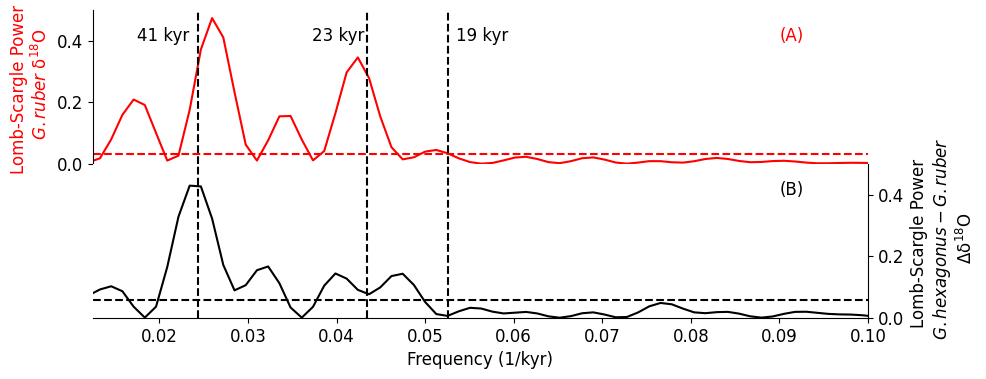

In [74]:
fig = plt.figure(constrained_layout=True, figsize=(10,10))
gs = gridspec.GridSpec(5,1)
gs.update(hspace=0)

ax1 = fig.add_subplot(gs[0,0])
ax1.plot(frequency6, power6, color='red')
ax1.plot(np.arange(0.01,0.11,0.01), np.zeros(10)+fa6,color='red',label='False Alarm Probability 5%',ls='--')
ax1.set_ylim(0,0.5)
ax1.set_xlim(1/80,1/10)

ax1.plot(np.zeros(5)+1/41, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')
ax1.text(0.0175,0.4,'41 kyr',color='black')
ax1.plot(np.zeros(5)+1/23, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')
ax1.text(0.03725,0.4,'23 kyr',color='black')
ax1.plot(np.zeros(5)+1/19, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')
ax1.text(0.0535,0.4,'19 kyr',color='black')

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.spines['left'].set_visible(True)
ax1.set_xticks([])
ax1.set_ylabel('Lomb-Scargle Power \n $G. ruber$ \u03b4$^{18}$O',color='red')
ax1.text(0.09,0.4, '(A)',color='red')

ax2 = fig.add_subplot(gs[1,0])
ax2.plot(frequency7, power7, color='black')
ax2.plot(np.arange(0.01,0.11,0.01), np.zeros(10)+fa7,color='black',label='False Alarm Probability 5%',ls='--')
ax2.set_ylim(0,0.5)
ax2.set_xlim(1/80,1/10)

ax2.plot(np.zeros(5)+1/41, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')
ax2.plot(np.zeros(5)+1/23, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')
ax2.plot(np.zeros(5)+1/19, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')

ax2.set_ylabel('Lomb-Scargle Power \n $G. hexagonus - G. ruber$ \n \u0394\u03b4$^{18}$O',color='black')
ax2.yaxis.tick_right()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(True)
ax2.spines['bottom'].set_visible(True)
ax2.spines['left'].set_visible(False)
ax2.yaxis.set_label_position("right")
ax2.text(0.09,0.4, '(B)',color='black')
ax2.set_xlabel('Frequency (1/kyr)')

plt.show()

## Supplementary Figure 9

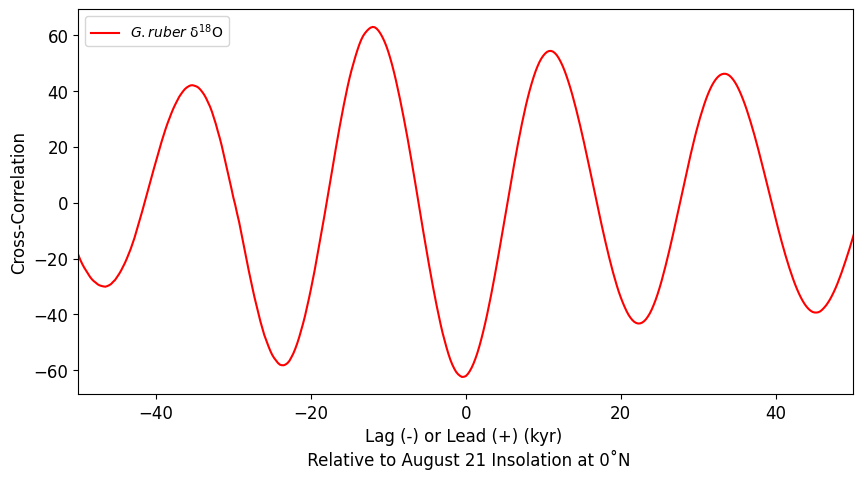

In [75]:
plt.figure(figsize=(10,5))
plt.plot(lags_rub, cross_corr_rub,color='red',label='$G. ruber$ \u03b4$^{18}$O')
plt.legend(loc='upper left',fontsize=10)
plt.xlim(-50,50)
plt.xlabel('Lag (-) or Lead (+) (kyr) \n Relative to August 21 Insolation at 0˚N')
plt.ylabel('Cross-Correlation')
plt.show()

## Supplementary Figure 9 
### To make Supplementary Figure 12, alter the resampling frequency to 3-kyr and re-run this code block

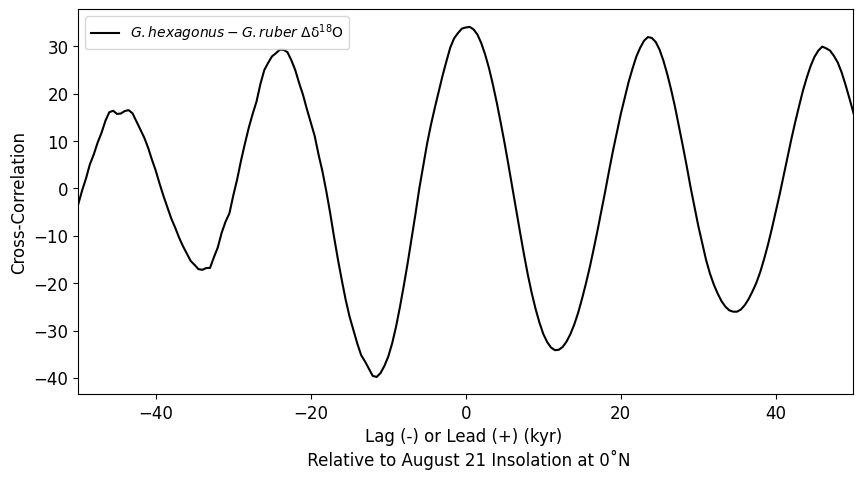

In [76]:
plt.figure(figsize=(10,5))
plt.plot(lags_hex_rub, cross_corr_hex_rub,color='black',label='$G. hexagonus - G. ruber$ \u0394\u03b4$^{18}$O')
plt.legend(loc='upper left',fontsize=10)
plt.xlim(-50,50)
# plt.ylim(-45,45)
plt.xlabel('Lag (-) or Lead (+) (kyr) \n Relative to August 21 Insolation at 0˚N')
plt.ylabel('Cross-Correlation')

plt.show()

## Supplementary Figure 11

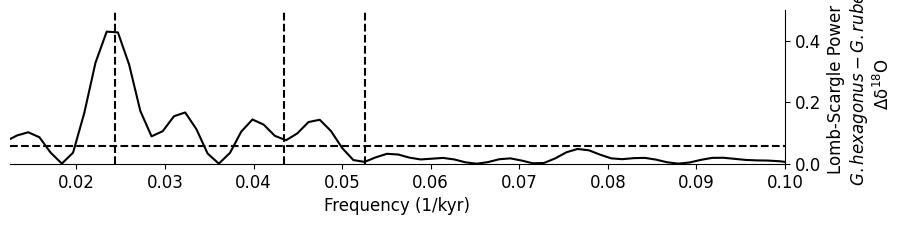

In [77]:
fig = plt.figure(constrained_layout=True, figsize=(10,10))
gs = gridspec.GridSpec(5,1)
gs.update(hspace=0)

ax2 = fig.add_subplot(gs[1,0])
ax2.plot(frequency7, power7, color='black')
ax2.plot(np.arange(0.01,0.11,0.01), np.zeros(10)+fa7,color='black',label='False Alarm Probability 5%',ls='--')
ax2.set_ylim(0,0.5)
ax2.set_xlim(1/80,1/10)

ax2.plot(np.zeros(5)+1/41, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')
ax2.plot(np.zeros(5)+1/23, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')
ax2.plot(np.zeros(5)+1/19, [0.0,0.2,0.3,0.4,0.9],color='black',ls='--')

ax2.set_ylabel('Lomb-Scargle Power \n $G. hexagonus - G. ruber$ \n \u0394\u03b4$^{18}$O',color='black')
ax2.yaxis.tick_right()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(True)
ax2.spines['bottom'].set_visible(True)
ax2.spines['left'].set_visible(False)
ax2.yaxis.set_label_position("right")
ax2.set_xlabel('Frequency (1/kyr)')

plt.show()

## Supplementary Figures 13 & 14

### Halve or double the resampling intervals, change the factors for cross correlations accordingly, and then re-run the code for Figure 5.

## Supplementary Figure 15

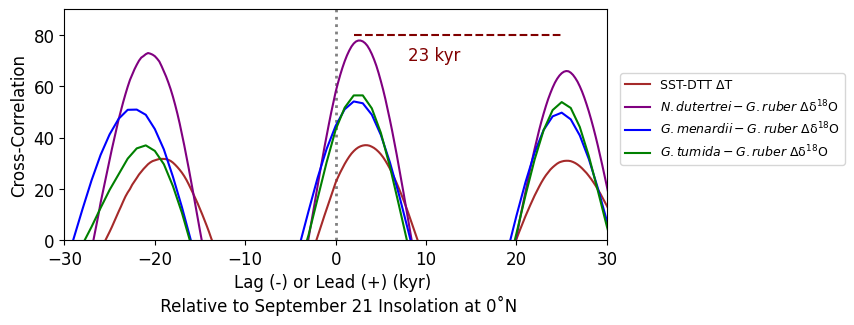

In [78]:
plt.figure(figsize=(7,3))
plt.plot(lags_mgca_dut_sept, cross_corr_mgca_dut_sept,color='brown',label='SST-DTT \u0394T',zorder=10)
plt.plot(lags_dut_rub_sept, cross_corr_dut_rub_sept,color='purple',label='$N. dutertrei - G. ruber$ \u0394\u03b4$^{18}$O',zorder=10)
plt.plot(lags_men_rub_sept, cross_corr_men_rub_sept,color='blue',label='$G. menardii - G. ruber$ \u0394\u03b4$^{18}$O',zorder=10)
plt.plot(lags_tum_rub_sept, cross_corr_tum_rub_sept,color='green',label='$G. tumida - G. ruber$ \u0394\u03b4$^{18}$O',zorder=10)

plt.xlabel('Lag (-) or Lead (+) (kyr) \n Relative to September 21 Insolation at 0˚N',fontsize=12)
plt.ylabel('Cross-Correlation',fontsize=12)
plt.xlim(-30,30)
plt.ylim(0,90)

plt.legend(loc='upper right', bbox_to_anchor=(1.45,0.75),ncol=1,prop={'size':9})

x = np.arange(2,26,1)
y = x*0 + 80

plt.plot(x,y,color='maroon',ls='--')
plt.text(8,70,'23 kyr',color='maroon',fontsize=12)
plt.axvline(x=0, color='grey', linestyle=':',lw=2)

plt.show()

## Supplementary Figure 16

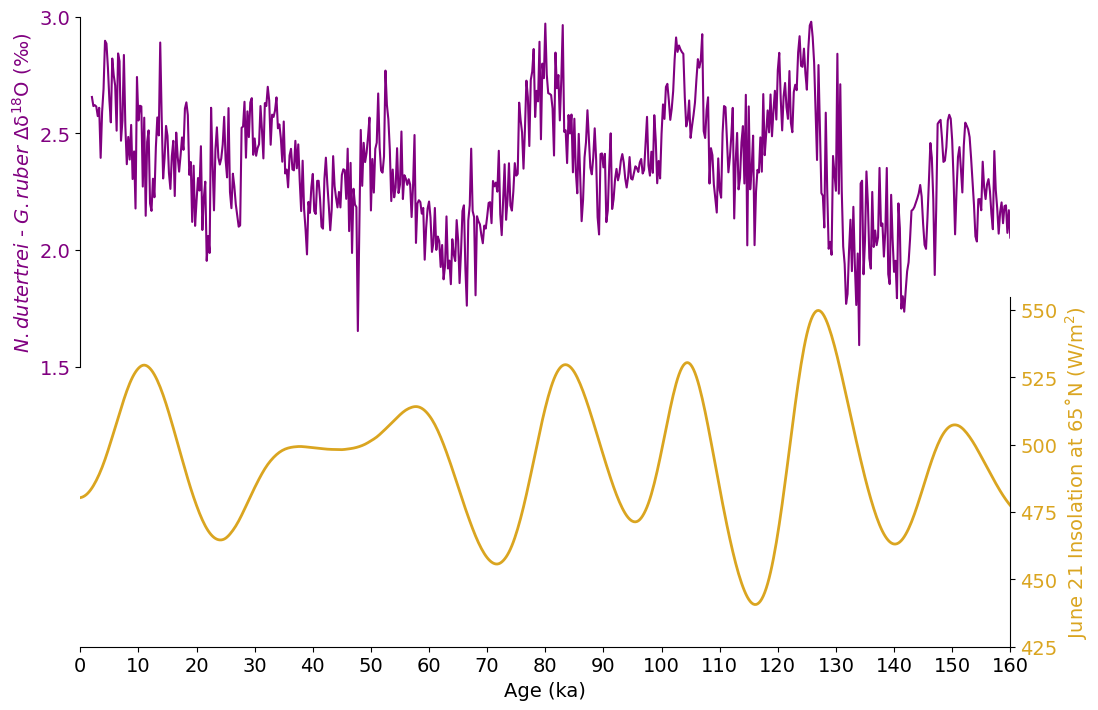

In [79]:
fig = plt.figure(constrained_layout=True, figsize=(12,7))
gs = gridspec.GridSpec(2,1)
plt.subplots_adjust(wspace=None, hspace=-2)

ax3 = fig.add_subplot(gs[0,0])
ax3.set_position([0.125, 1, 0.775, 0.5]) 
ax3.set_facecolor('#FFFFFF00')

ax3.set_xticks([])
ax3.set_facecolor('#FFFFFF00')
ax3.set_xlim(0,160)
ax3.plot(dif_dut['age_ka'],dif_dut['dif'],color='purple')
ax3.set_ylim(1.5,3)
ax3.set_ylabel('$N. dutertrei$ - $G. ruber$ \u0394\u03b4$^{18}$O (\u2030)',size=14,color='purple')

yticks = np.round(np.arange(1.5,3.1,0.5),1)
ax3.set_yticks(yticks)
ax3.set_yticklabels(yticks,size=14,color='purple')
ax3.yaxis.tick_left()
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['bottom'].set_visible(False)
ax3.spines['left'].set_visible(True)
ax3.yaxis.set_label_position("left")

ax4 = fig.add_subplot(gs[1,0])
ax4.set_position([0.125, 0.6, 0.775, 0.5]) 
ax4.set_facecolor('#FFFFFF00')

ax4.plot(nhsi['age_ka'],nhsi['insol_june_65_wm2'], color='goldenrod', lw=2)
ax4.set_ylabel('June 21 Insolation at 65˚N (W/m$^{2}$)',size=14,color='goldenrod')

ax4.set_ylim(425,555)
ax4.set_xlim(0,160)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(True)
ax4.spines['bottom'].set_visible(True)
ax4.spines['left'].set_visible(False)
ax4.yaxis.set_label_position("right")
ax4.yaxis.tick_right()
yticks = np.round(np.arange(425,555,25),2)
ax4.set_yticks(yticks)
ax4.set_yticklabels(yticks,size=14,color='goldenrod')
ax4.set_xlabel('Age (ka)', fontsize=14)
xticks = np.arange(0,165,10)
ax4.set_xticks(xticks)
ax4.set_xticklabels(xticks, fontsize=14);

plt.show()

## Supplementary Figure 17

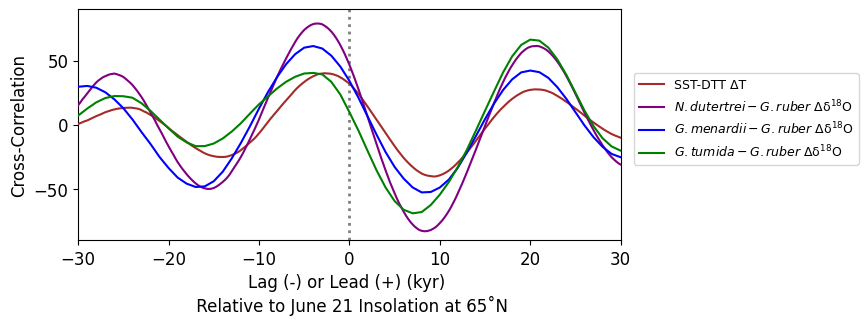

In [80]:
plt.figure(figsize=(7,3))
plt.plot(lags_mgca_dut_june, cross_corr_mgca_dut_june,color='brown',label='SST-DTT \u0394T',zorder=10)
plt.plot(lags_dut_rub_june, cross_corr_dut_rub_june,color='purple',label='$N. dutertrei - G. ruber$ \u0394\u03b4$^{18}$O',zorder=10)
plt.plot(lags_men_rub_june, cross_corr_men_rub_june,color='blue',label='$G. menardii - G. ruber$ \u0394\u03b4$^{18}$O',zorder=10)
plt.plot(lags_tum_rub_june, cross_corr_tum_rub_june,color='green',label='$G. tumida - G. ruber$ \u0394\u03b4$^{18}$O',zorder=10)

plt.xlabel('Lag (-) or Lead (+) (kyr) \n Relative to June 21 Insolation at 65˚N',fontsize=12)
plt.ylabel('Cross-Correlation',fontsize=12)
plt.xlim(-30,30)
plt.ylim(-90,90)

plt.legend(loc='upper right', bbox_to_anchor=(1.45,0.75),ncol=1,prop={'size':9})
plt.axvline(x=0, color='grey', linestyle=':',lw=2)
plt.show()

## Supplementary Figure 18

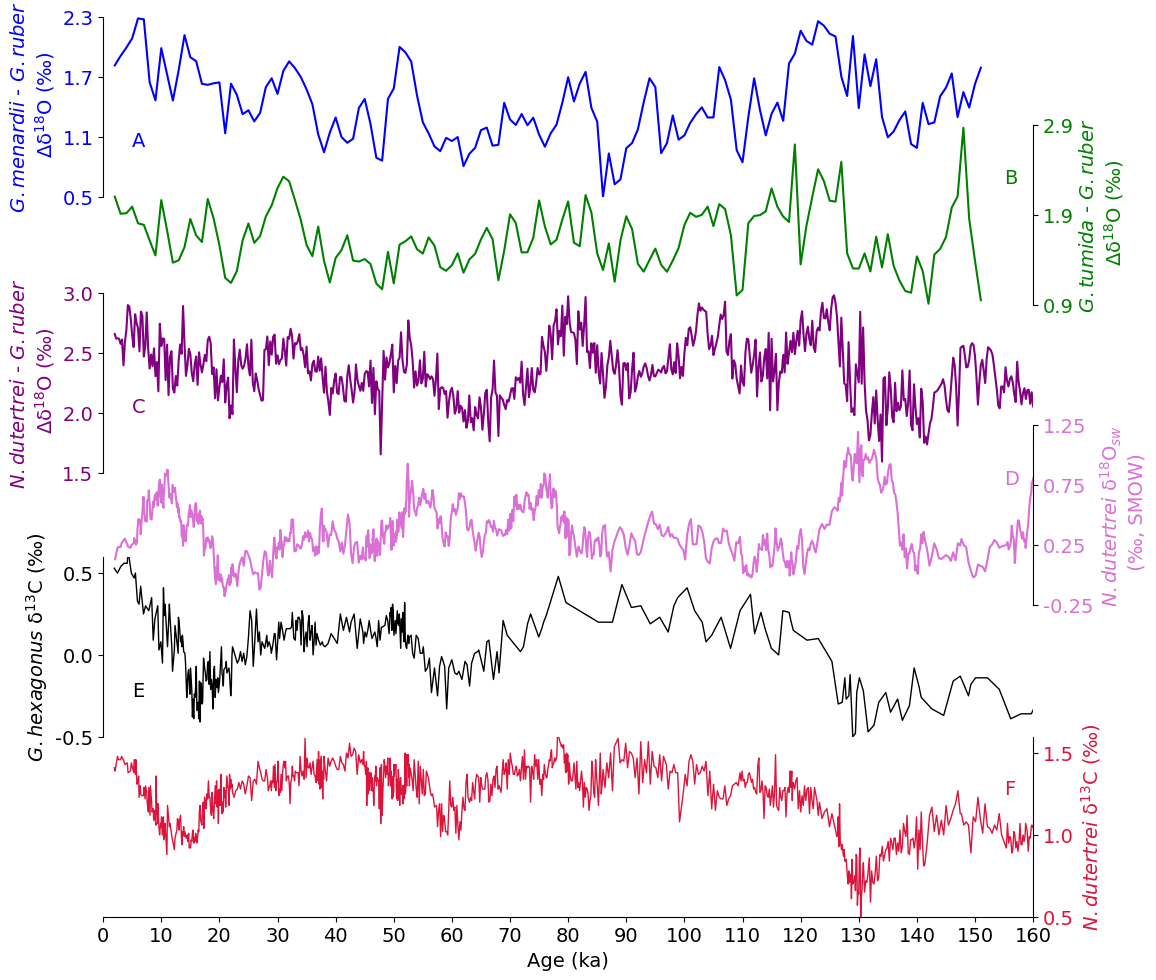

In [81]:
fig = plt.figure(constrained_layout=True, figsize=(12,12))
gs = gridspec.GridSpec(8,1)
plt.subplots_adjust(wspace=None, hspace=-.3)

ax2 = fig.add_subplot(gs[1,0])

ax2.set_position([0.125, 0.8, 0.775, 0.15]) 

ax2.set_facecolor('#FFFFFF00')
ax2.set_xlim(0,160)
ax2.set_xticks([])
ax2.plot(dif_men['age_ka'],dif_men['dif'],color='blue')

ax2.set_ylim(0.5,2.3)
ax2.set_ylabel('$G. menardii$ - $G. ruber$ \n \u0394\u03b4$^{18}$O (\u2030)',size=14,color='blue')
yticks = np.round(np.arange(0.5,2.4,0.6),2)
ax2.set_yticks(yticks)
ax2.set_yticklabels(yticks,size=14,color='blue')
ax2.yaxis.tick_left()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(True)
ax2.yaxis.set_label_position("left")
ax2.text(5,1,'A',size=14,color='blue')

ax2b = fig.add_subplot(gs[2,0])

ax2b.set_position([0.125, 0.71, 0.775, 0.15]) 

ax2b.set_facecolor('#FFFFFF00')
ax2b.set_xlim(0,160)
ax2b.set_xticks([])
ax2b.plot(dif_tum['age_ka'],dif_tum['dif'],color='green')
ax2b.set_ylabel('$G. tumida$ - $G. ruber$ \n \u0394\u03b4$^{18}$O (\u2030)',size=14,color='green')
ax2b.spines['top'].set_visible(False)
ax2b.spines['right'].set_visible(True)
ax2b.spines['bottom'].set_visible(False)
ax2b.spines['left'].set_visible(False)
ax2b.set_ylim(0.9,2.9)
yticks = np.round(np.arange(0.9,3,1),2)
ax2b.set_yticks(yticks)
ax2b.set_yticklabels(yticks,size=14,color='green')
ax2b.yaxis.tick_right()
ax2b.yaxis.set_label_position("right")
ax2b.text(155,2.25,'B',size=14,color='green')

ax3 = fig.add_subplot(gs[3,0])

ax3.set_position([0.125, 0.57, 0.775, 0.15]) 

ax3.set_xticks([])
ax3.set_facecolor('#FFFFFF00')
ax3.set_xlim(0,160)
ax3.plot(dif_dut['age_ka'],dif_dut['dif'],color='purple')
ax3.set_ylim(1.5,3)
ax3.set_ylabel('$N. dutertrei$ - $G. ruber$ \n \u0394\u03b4$^{18}$O (\u2030)',size=14,color='purple')

yticks = np.round(np.arange(1.5,3.1,0.5),1)
ax3.set_yticks(yticks)
ax3.set_yticklabels(yticks,size=14,color='purple')
ax3.yaxis.tick_left()
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['bottom'].set_visible(False)
ax3.spines['left'].set_visible(True)
ax3.yaxis.set_label_position("left")
ax3.text(5,2,'C',size=14,color='purple')

ax4 = fig.add_subplot(gs[4,0])
ax4.set_position([0.125, 0.46, 0.775, 0.15]) 

ax4.set_xticks([])
ax4.set_facecolor('#FFFFFF00')
ax4.set_xlim(0,160)
ax4.plot(d18Osw_dut['age_ka'],d18Osw_dut['N. dutertrei δ18O seawater average (‰) SMOW'],color='orchid')
ax4.set_ylim(-0.25,1.25)
ax4.set_ylabel('$N. dutertrei$ \u03b4$^{18}$O$_{sw}$ \n (\u2030, SMOW)',size=14,color='orchid')

yticks = np.round(np.arange(-0.25,1.3,0.5),2)
ax4.set_yticks(yticks)
ax4.set_yticklabels(yticks,size=14,color='orchid')
ax4.yaxis.tick_right()
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(True)
ax4.spines['bottom'].set_visible(False)
ax4.spines['left'].set_visible(False)
ax4.yaxis.set_label_position("right")
ax4.text(155,0.75,'D',color='orchid',size=14)


ax5 = fig.add_subplot(gs[5,0])

ax5.set_position([0.125, 0.35, 0.775, 0.15]) 

ax5.set_facecolor('#FFFFFF00')
ax5.set_xlim(0,160)
ax5.plot(hex13C['age_ka'],hex13C['G. hexagonus δ13C (‰) VPDB'],color='black',lw=1)
ax5.set_ylim(-0.5,0.6)
ax5.set_ylabel('$G. hexagonus$ \u03b4$^{13}$C (\u2030)',fontsize=14, color='black')

yticks = np.round(np.arange(-0.5,0.6,0.5),1)
ax5.set_yticks(yticks)
ax5.set_yticklabels(yticks,size=14, color='black')
ax5.yaxis.tick_left()
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.spines['bottom'].set_visible(False)
ax5.spines['left'].set_visible(True)
ax5.yaxis.set_label_position("left")
ax5.set_xticks([])
ax5.text(5, -0.25, 'E', size=14, color='black')

ax6 = fig.add_subplot(gs[6,0])

ax6.set_position([0.125, 0.2, 0.775, 0.15]) 

ax6.set_facecolor('#FFFFFF00')
ax6.set_xlim(0,160)
ax6.plot(pena2008_duter_13C['age_ka'],pena2008_duter_13C['N. dutertrei δ13C (‰) VPDB'],color='crimson',lw=1)
ax6.set_ylim(0.5,1.6)
ax6.set_ylabel('$N. dutertrei$ \u03b4$^{13}$C (\u2030)',fontsize=14, color='crimson')

yticks = np.round(np.arange(0.5,1.6,0.5),1)
ax6.set_yticks(yticks)
ax6.set_yticklabels(yticks,size=14, color='crimson')
ax6.yaxis.tick_right()
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(True)
ax6.spines['bottom'].set_visible(True)
ax6.spines['left'].set_visible(False)
ax6.yaxis.set_label_position("right")
ax6.text(155, 1.25, 'F', size=14, color='crimson')
ax6.set_xlabel('Age (ka)', fontsize=14)
xticks = np.arange(0,165,10)
ax6.set_xticks(xticks)
ax6.set_xticklabels(xticks, fontsize=14);

plt.show()

## Supplementary Figure 19

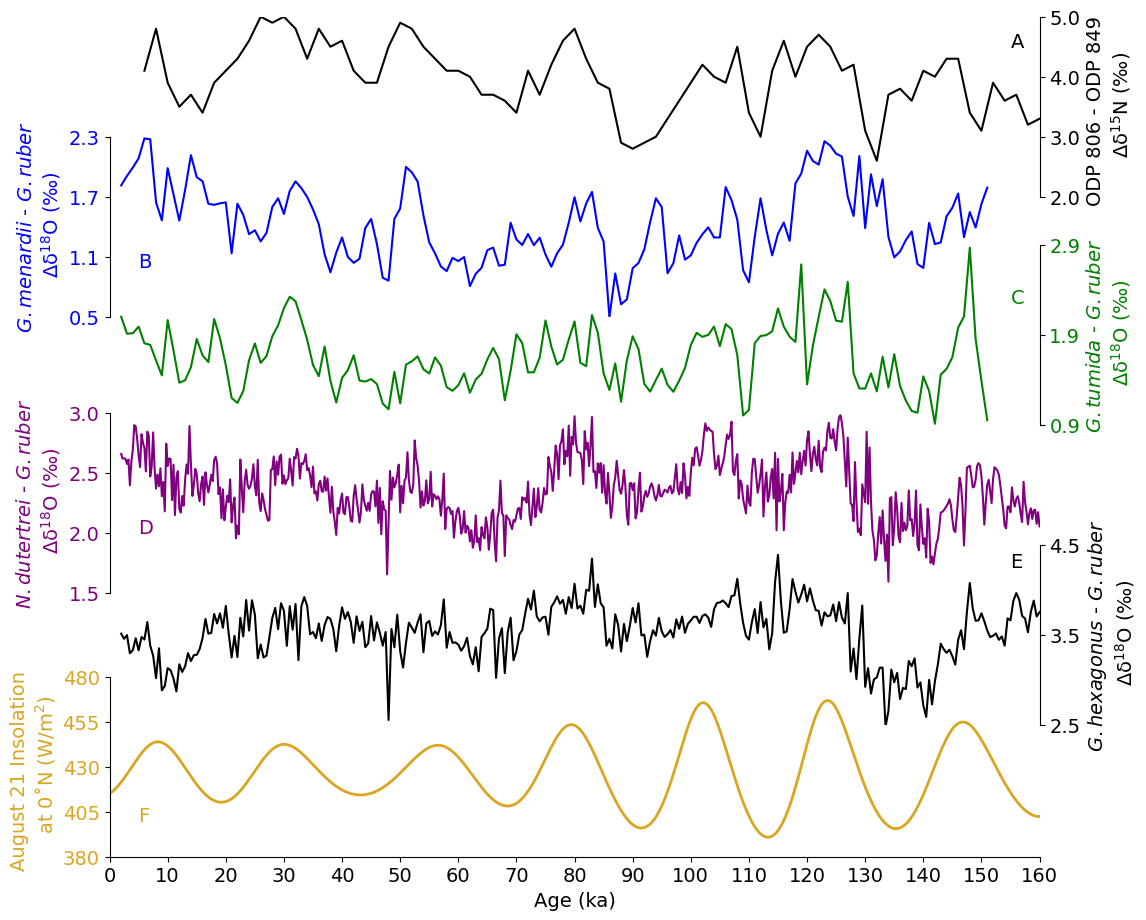

In [82]:
fig = plt.figure(constrained_layout=True, figsize=(12,12))
gs = gridspec.GridSpec(8,1)
plt.subplots_adjust(wspace=None, hspace=-.3)

ax1 = fig.add_subplot(gs[1,0])

ax1.set_position([0.125, 0.9, 0.775, 0.15]) 

ax1.set_facecolor('#FFFFFF00')
ax1.set_xlim(0,160)
ax1.set_ylim(2,5)
yticks = np.arange(2,5.5,1)
ax1.set_yticks(yticks)
ax1.set_yticklabels(yticks,size=14,color='black')
ax1.set_xticks([])
ax1.plot(rafter['age_calkaBP'],rafter['dd15N'],color='black')
ax1.yaxis.tick_right()
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(True)
ax1.spines['bottom'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.yaxis.set_label_position("right")
ax1.text(155, 4.5,'A',size=14,color='black')
ax1.set_ylabel('ODP 806 - ODP 849 \n \u0394\u03b4$^{15}$N (\u2030)',size=14,color='black')


ax2 = fig.add_subplot(gs[1,0])

ax2.set_position([0.125, 0.8, 0.775, 0.15]) 

ax2.set_facecolor('#FFFFFF00')
ax2.set_xlim(0,160)
ax2.set_xticks([])
ax2.plot(dif_men['age_ka'],dif_men['dif'],color='blue')

ax2.set_ylim(0.5,2.3)
ax2.set_ylabel('$G. menardii$ - $G. ruber$ \n \u0394\u03b4$^{18}$O (\u2030)',size=14,color='blue')
yticks = np.round(np.arange(0.5,2.4,0.6),2)
ax2.set_yticks(yticks)
ax2.set_yticklabels(yticks,size=14,color='blue')
ax2.yaxis.tick_left()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(True)
ax2.yaxis.set_label_position("left")
ax2.text(5,1,'B',size=14,color='blue')

ax2b = fig.add_subplot(gs[2,0])

ax2b.set_position([0.125, 0.71, 0.775, 0.15]) 

ax2b.set_facecolor('#FFFFFF00')
ax2b.set_xlim(0,160)
ax2b.set_xticks([])
ax2b.plot(dif_tum['age_ka'],dif_tum['dif'],color='green')
ax2b.set_ylabel('$G. tumida$ - $G. ruber$ \n \u0394\u03b4$^{18}$O (\u2030)',size=14,color='green')
ax2b.spines['top'].set_visible(False)
ax2b.spines['right'].set_visible(True)
ax2b.spines['bottom'].set_visible(False)
ax2b.spines['left'].set_visible(False)
ax2b.set_ylim(0.9,2.9)
yticks = np.round(np.arange(0.9,3,1),2)
ax2b.set_yticks(yticks)
ax2b.set_yticklabels(yticks,size=14,color='green')
ax2b.yaxis.tick_right()
ax2b.yaxis.set_label_position("right")
ax2b.text(155,2.25,'C',size=14,color='green')

ax3 = fig.add_subplot(gs[3,0])

ax3.set_position([0.125, 0.57, 0.775, 0.15]) 

ax3.set_xticks([])
ax3.set_facecolor('#FFFFFF00')
ax3.set_xlim(0,160)
ax3.plot(dif_dut['age_ka'],dif_dut['dif'],color='purple')
ax3.set_ylim(1.5,3)
ax3.set_ylabel('$N. dutertrei$ - $G. ruber$ \n \u0394\u03b4$^{18}$O (\u2030)',size=14,color='purple')

yticks = np.round(np.arange(1.5,3.1,0.5),1)
ax3.set_yticks(yticks)
ax3.set_yticklabels(yticks,size=14,color='purple')
ax3.yaxis.tick_left()
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['bottom'].set_visible(False)
ax3.spines['left'].set_visible(True)
ax3.yaxis.set_label_position("left")
ax3.text(5,2,'D',size=14,color='purple')

ax4 = fig.add_subplot(gs[4,0])
ax4.set_position([0.125, 0.46, 0.775, 0.15]) 

ax4.set_xticks([])
ax4.set_facecolor('#FFFFFF00')
ax4.set_xlim(0,160)
ax4.plot(dif_hex['age_ka'],dif_hex['dif'],color='black')
ax4.set_ylim(2.5,4.5)
ax4.set_ylabel('$G. hexagonus$ - $G. ruber$ \n \u0394\u03b4$^{18}$O (\u2030)',size=14,color='black')

yticks = np.round(np.arange(2.5,4.6,1),2)
ax4.set_yticks(yticks)
ax4.set_yticklabels(yticks,size=14)
ax4.yaxis.tick_right()
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(True)
ax4.spines['bottom'].set_visible(False)
ax4.spines['left'].set_visible(False)
ax4.yaxis.set_label_position("right")
ax4.text(155,4.25,'E',size=14)

ax5 = fig.add_subplot(gs[5,0])

ax5.set_position([0.125, 0.35, 0.775, 0.15]) 

ax5.set_facecolor('#FFFFFF00')
ax5.set_xlim(0,160)
ax5.plot(august['age_ka'],august['insol_aug_0_wm2'],color='goldenrod',lw=2)
ax5.set_ylim(380,480)
ax5.set_ylabel('August 21 Insolation \n at 0˚N (W/m$^{2}$)',fontsize=14, color='goldenrod')

yticks = np.round(np.arange(380,481,25),0)
ax5.set_yticks(yticks)
ax5.set_yticklabels(yticks,size=14, color='goldenrod')
ax5.yaxis.tick_left()
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.spines['bottom'].set_visible(True)
ax5.spines['left'].set_visible(True)
ax5.yaxis.set_label_position("left")
ax5.text(5, 400, 'F', size=14, color='goldenrod')
ax5.set_xlabel('Age (ka)', fontsize=14)
xticks = np.arange(0,165,10)
ax5.set_xticks(xticks)
ax5.set_xticklabels(xticks, fontsize=14);

plt.show()